#### 📚 Importacion de librerias

In [1]:
# Librerias
import os # Se utiliza para listar archivos y navegar por el sistema de archivos
from pathlib import Path # Se utiliza para manejar rutas de archivos de manera eficiente

import pandas as pd # Se utiliza para crear y manipular DataFrames
import numpy as np # Se utiliza para realizar operaciones matemáticas y manipulación de datos
import matplotlib.pyplot as plt # Se utiliza para crear gráficos y visualizaciones
import seaborn as sns # Se utiliza para crear gráficos estadísticos atractivos y personalizables
from scipy import stats # Se utiliza para realizar pruebas estadísticas y calcular estadísticos
from sklearn.metrics import roc_auc_score # Se utiliza para calcular el AUC-ROC, una métrica de rendimiento para modelos de clasificación
from scipy.stats import spearmanr # Se utiliza para calcular la correlación de Spearman entre dos variables

# Config básica de plots
plt.style.use("default")
sns.set_palette("husl")

# Configuración de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.2f}".format)

#### ⏫ Importacion de datos

In [2]:
# Paths base
BASE_DIR = Path().resolve().parent if (Path().resolve().name == "notebooks") else Path().resolve()
DATA_DIR = BASE_DIR / "data" / "raw"

BASE_DIR, DATA_DIR

# Listar archivos raw y elegir el último por fecha de modificación
raw_files = sorted(
    DATA_DIR.glob("spotify_tracks_merged_raw_*.parquet"),
    key=os.path.getmtime,
)

raw_files[-5:]  # Visualizar los últimos 5 archivos

latest_raw_path = raw_files[-1]
print("Usando archivo:", latest_raw_path)

# Armado del dataframe
df = pd.read_parquet(latest_raw_path)

Usando archivo: /Users/nicoguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/data/raw/spotify_tracks_merged_raw_20260224_150507.parquet


#### 📊 Información General del Dataset


In [3]:
# Información general del dataframe
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
print(f"\nDimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nTamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n")
df.info()

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 66,156 filas x 16 columnas

Tamaño en memoria: 52.14 MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66156 entries, 0 to 66155
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   track_id            66156 non-null  object
 1   track_name          66156 non-null  object
 2   track_popularity    66156 non-null  int64 
 3   duration_ms         66156 non-null  int64 
 4   explicit            66156 non-null  bool  
 5   album_id            66156 non-null  object
 6   album_name          66156 non-null  object
 7   album_release_date  66126 non-null  object
 8   artist_id           66156 non-null  object
 9   artist_name         66126 non-null  object
 10  playlist_id         62111 non-null  object
 11  playlist_name       62111 non-null  object
 12  added_at            1656 non-null   object
 13  source              66156 non-null  object
 14  search_query  

In [4]:
print("=" * 80)
print("IMPRESION DE LAS PRIMERAS 15 FILAS")
print("=" * 80)
df.head(15)

IMPRESION DE LAS PRIMERAS 15 FILAS


,track_id,track_name,track_popularity,duration_ms,explicit,album_id,album_name,album_release_date,artist_id,artist_name,playlist_id,playlist_name,added_at,source,search_query,search_market
0,7Dev2VJdJKwIIUdj3lcQl9,Release The Pressure,73,203668,False,3mFlg0trNYSCnTd0RcN0wx,Release The Pressure,2026-02-06,7CajNmpbOovFoOoasH2HaY,Calvin Harris,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
1,09CnYHiZ5jGT1wr1TXJ9Zt,Thank You (Not So Bad),82,140000,False,1J7XItLnNLegigdh4AjGKN,Thank You (Not So Bad),2023-12-01,73jBynjsVtofjRpdpRAJGk,Dimitri Vegas & Like Mike,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
2,2qlqMa0e422LZyGw1J5for,YEAH,69,141551,True,3reHnBJbOMrlymwkwYqtEH,YEAH,2025-03-14,73jBynjsVtofjRpdpRAJGk,Dimitri Vegas & Like Mike,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
3,1Q9AA6bYXxJBXPxBeQsLf5,Freed From Desire,67,154400,False,1292CkAdy9w965GZ4ujR8d,Freed From Desire,2025-10-23,5v8NhwxY9vLSXmoLLBIobl,WESCALATIE,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
4,4a1UArX9uL4trMks4wu8LZ,Crazy,64,125625,False,4xQKZ1vTOvkaPJWaA0AFEg,Crazy,2026-01-16,21dVknSLCsK37cWozWDZZS,Matt Sassari,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
5,1OcV53oesLQw3VTW9I3uD3,Waterfalls (feat. Sam Harper & Bobby Harvey),80,120578,False,1iEczV3pKJ9MPmRvYGB9bz,Waterfalls (feat. Sam Harper & Bobby Harvey),2025-08-08,43BxCL6t4c73BQnIJtry5v,James Hype,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
6,2yowklsfVsIsMaKhuO0Vh1,Promises,65,143376,False,04h30GXR8nVJXqqX3Ubvyi,Promises,2025-05-23,3MWeawb18cHiDxt4ip7GY9,BOVSKI,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
7,4Pd6KvXa6DVEA5Wr41k9Dw,think you're someone new,71,150583,True,4nlBHc4E4s3L1E6NxoIta2,think you're someone new,2026-01-30,5IrxhrMyvZxzgPYrC9j2km,Ian Asher,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
8,2FAZskT9yRjp2Oow9szJD8,The Days - NOTION Remix,86,233229,False,15gT6ikjvzrlIxQ5eTpqLJ,The Days (NOTION Remix),2024-11-08,5bQ3wFgekuIMIcWJuxkqLK,Chrystal,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None
9,3BlHcmJ9ii6OCweTceTPOf,How Do You Do,68,143624,False,6qqqNQad2EdGjxJon21DxC,How Do You Do,2025-09-19,5AhNxN49kLHc9ry5GkMs09,The Infamous,2237sMNMlXS4wWLgdQ1UuV,Workout Motivation 2026 💪,2026-02-23T13:55:47Z,user_playlists,None,None


#### 🔍 Análisis de Valores Nulos


ANÁLISIS DE VALORES NULOS

Columnas con valores nulos: 7
           Columna  Nulos  Porcentaje
          added_at  64500       97.50
      search_query  62111       93.89
     search_market  62111       93.89
       playlist_id   4045        6.11
     playlist_name   4045        6.11
       artist_name     30        0.05
album_release_date     30        0.05


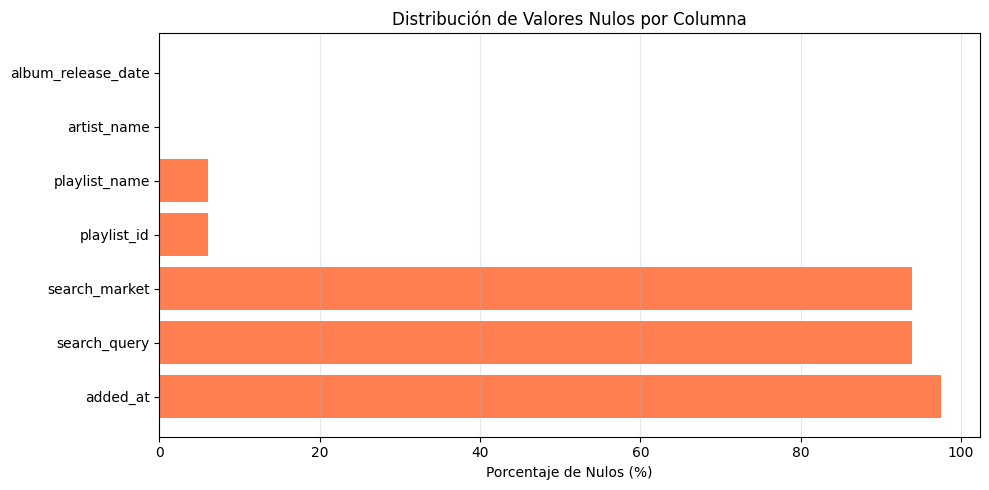

In [5]:
# Análisis de valores nulos
nulos = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': df.isnull().sum().values,
    'Porcentaje': (df.isnull().sum().values / len(df) * 100).round(2)
})
nulos = nulos[nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

print("=" * 80)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 80)
if len(nulos) > 0:
    print(f"\nColumnas con valores nulos: {len(nulos)}")
    print(nulos.to_string(index=False))
else:
    print("\n✓ No hay valores nulos en el dataset")
    
# Visualización de nulos
if len(nulos) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(nulos['Columna'], nulos['Porcentaje'], color='coral')
    ax.set_xlabel('Porcentaje de Nulos (%)')
    ax.set_title('Distribución de Valores Nulos por Columna')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


#### 🔄 Análisis de Duplicados


In [6]:
# Análisis de duplicados
print("=" * 80)
print("ANÁLISIS DE DUPLICADOS")
print("=" * 80)

# Filas completamente duplicadas
duplicados_totales = df.duplicated().sum()
print(f"\nFilas completamente duplicadas: {duplicados_totales:,} ({duplicados_totales/len(df)*100:.2f}%)")

# Duplicados por track_id
duplicados_tracks = df.duplicated(subset=['track_id']).sum()
print(f"Tracks duplicados (mismo track_id): {duplicados_tracks:,} ({duplicados_tracks/len(df)*100:.2f}%)")

# Duplicados por combinación track-playlist
duplicados_track_playlist = df.duplicated(subset=['track_id', 'playlist_id']).sum()
print(f"Duplicados track-playlist: {duplicados_track_playlist:,} ({duplicados_track_playlist/len(df)*100:.2f}%)")

# Tracks únicos
print(f"\nTracks únicos: {df['track_id'].nunique():,}")
print(f"Playlists únicas: {df['playlist_id'].nunique():,}")
print(f"Artistas únicos: {df['artist_id'].nunique():,}")
print(f"Álbumes únicos: {df['album_id'].nunique():,}")


ANÁLISIS DE DUPLICADOS

Filas completamente duplicadas: 0 (0.00%)
Tracks duplicados (mismo track_id): 0 (0.00%)
Duplicados track-playlist: 0 (0.00%)

Tracks únicos: 66,156
Playlists únicas: 389
Artistas únicos: 18,871
Álbumes únicos: 50,959


#### 📈 Análisis de Variables Numéricas


In [7]:
# Estadísticas descriptivas de variables numéricas
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
print("\n")

# Convertir duración a minutos para mejor interpretación
df['duration_min'] = df['duration_ms'] / 60000

numeric_cols = ['track_popularity', 'duration_ms', 'duration_min']
print(df[numeric_cols].describe().T)

print("\n" + "=" * 80)
print("ANÁLISIS ADICIONAL")
print("=" * 80)
print(f"\nDuración promedio de tracks: {df['duration_min'].mean():.2f} minutos")
print(f"Duración mínima: {df['duration_min'].min():.2f} minutos")
print(f"Duración máxima: {df['duration_min'].max():.2f} minutos")
print(f"\nPopularidad promedio: {df['track_popularity'].mean():.2f}")
print(f"Tracks con popularidad 0: {(df['track_popularity'] == 0).sum():,} ({(df['track_popularity'] == 0).sum()/len(df)*100:.2f}%)")
print(f"Tracks con popularidad > 50: {(df['track_popularity'] > 50).sum():,} ({(df['track_popularity'] > 50).sum()/len(df)*100:.2f}%)")


ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


                    count      mean      std  min       25%       50%  \
track_popularity 66156.00     36.40    24.16 0.00     17.00     38.00   
duration_ms      66156.00 202631.74 86748.36 0.00 157073.00 193853.00   
duration_min     66156.00      3.38     1.45 0.00      2.62      3.23   

                       75%        max  
track_popularity     55.00     100.00  
duration_ms      232800.00 7849728.00  
duration_min          3.88     130.83  

ANÁLISIS ADICIONAL

Duración promedio de tracks: 3.38 minutos
Duración mínima: 0.00 minutos
Duración máxima: 130.83 minutos

Popularidad promedio: 36.40
Tracks con popularidad 0: 9,389 (14.19%)
Tracks con popularidad > 50: 20,596 (31.13%)


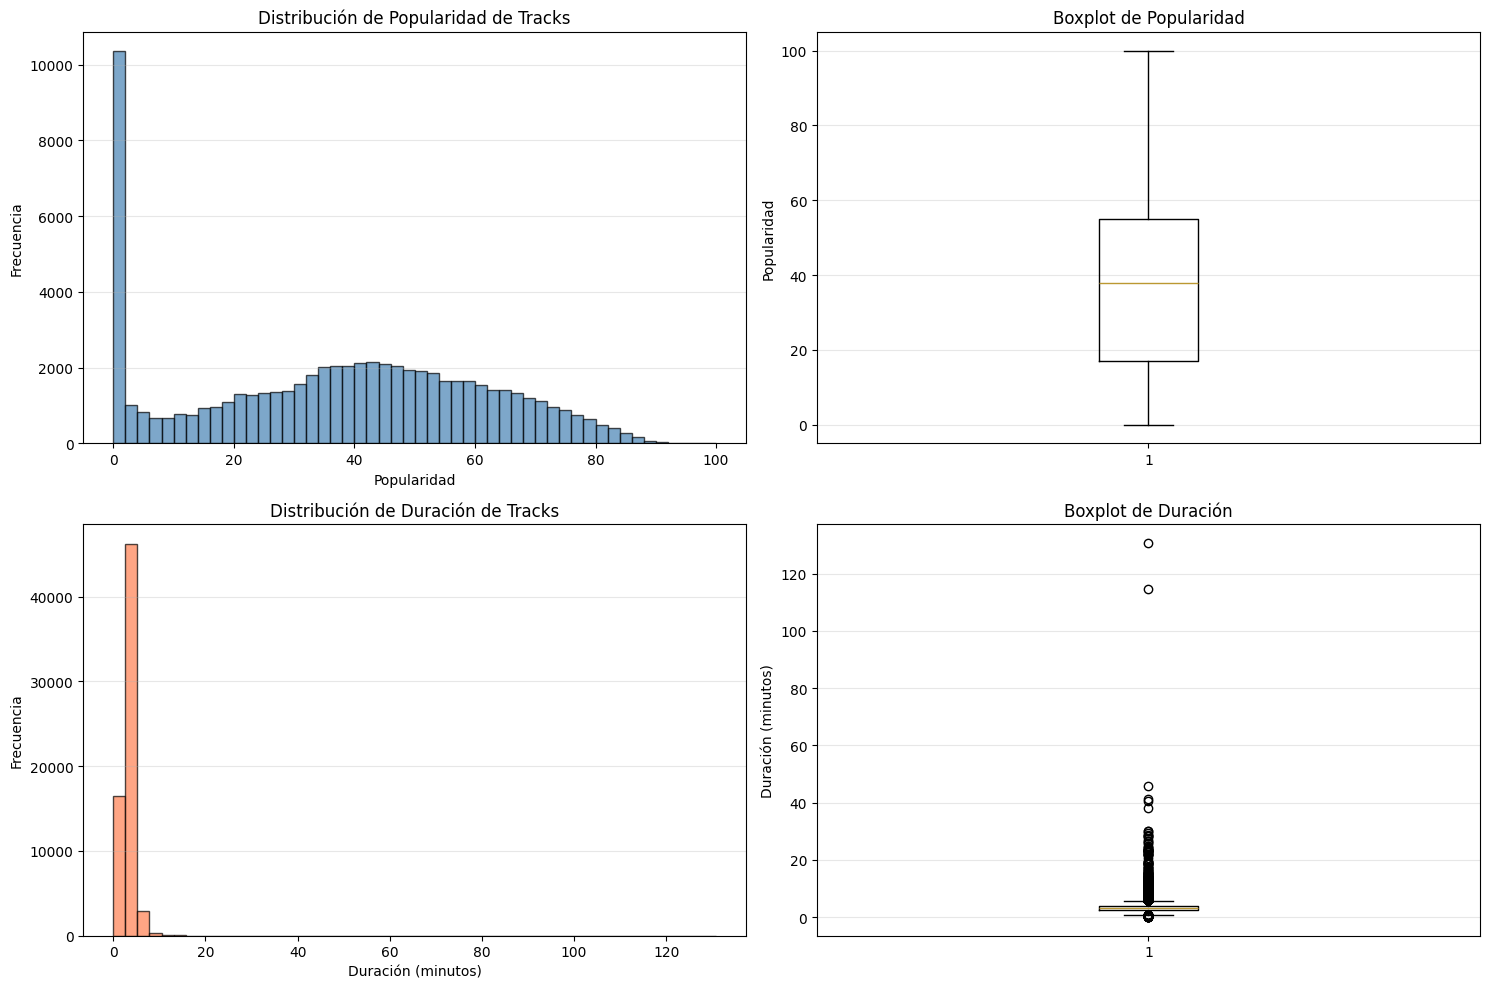

In [8]:
# Visualización de distribuciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de popularidad
axes[0, 0].hist(df['track_popularity'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Popularidad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Popularidad de Tracks')
axes[0, 0].grid(axis='y', alpha=0.3)

# Boxplot de popularidad
axes[0, 1].boxplot(df['track_popularity'], vert=True)
axes[0, 1].set_ylabel('Popularidad')
axes[0, 1].set_title('Boxplot de Popularidad')
axes[0, 1].grid(axis='y', alpha=0.3)

# Distribución de duración (en minutos)
axes[1, 0].hist(df['duration_min'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Duración (minutos)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Duración de Tracks')
axes[1, 0].grid(axis='y', alpha=0.3)

# Boxplot de duración
axes[1, 1].boxplot(df['duration_min'], vert=True)
axes[1, 1].set_ylabel('Duración (minutos)')
axes[1, 1].set_title('Boxplot de Duración')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


#### 📊 Análisis de Variables Categóricas


In [9]:
# Análisis de contenido explícito
print("=" * 80)
print("ANÁLISIS DE CONTENIDO EXPLÍCITO")
print("=" * 80)

# Cantidad de tracks explícitos
explicit_counts = df['explicit'].value_counts()
print(f"\n{explicit_counts}")
print(f"\nPorcentaje de tracks explícitos: {(explicit_counts.get(True, 0)/len(df)*100):.2f}%")

# Top 10 artistas con más tracks
print("\n" + "=" * 80)
print("TOP 10 ARTISTAS CON MÁS TRACKS")
print("=" * 80)
top_artists = df.groupby('artist_name').size().sort_values(ascending=False).head(10)
print(top_artists)

# Top 10 playlists con más tracks
print("\n" + "=" * 80)
print("TOP 10 PLAYLISTS CON MÁS TRACKS")
print("=" * 80)
top_playlists = df.groupby('playlist_name').size().sort_values(ascending=False).head(10)
print(top_playlists)

# Top 10 álbumes con más tracks
print("\n" + "=" * 80)
print("TOP 10 ÁLBUMES CON MÁS TRACKS")
print("=" * 80)
top_albums = df.groupby('album_name').size().sort_values(ascending=False).head(10)
print(top_albums)


ANÁLISIS DE CONTENIDO EXPLÍCITO

explicit
False    57056
True      9100
Name: count, dtype: int64

Porcentaje de tracks explícitos: 13.76%

TOP 10 ARTISTAS CON MÁS TRACKS
artist_name
Los Palmeras     289
Dans             229
Daddy Yankee     193
Taylor Swift     174
Duki             163
Bad Bunny        143
Miracle Tones    137
Don Omar         137
lofi cassette    137
David Guetta     133
dtype: int64

TOP 10 PLAYLISTS CON MÁS TRACKS
playlist_name
Mex                                                                                                   529
Reggaeton viejo                                                                                       414
house oscuro + indie dance                                                                            400
INSTRUMENTAL COVERS 2026 ✨ popular songs                                                              400
Calm & Focused                                                                                        399
Focus Music - Wor

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/432900883.py:39: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


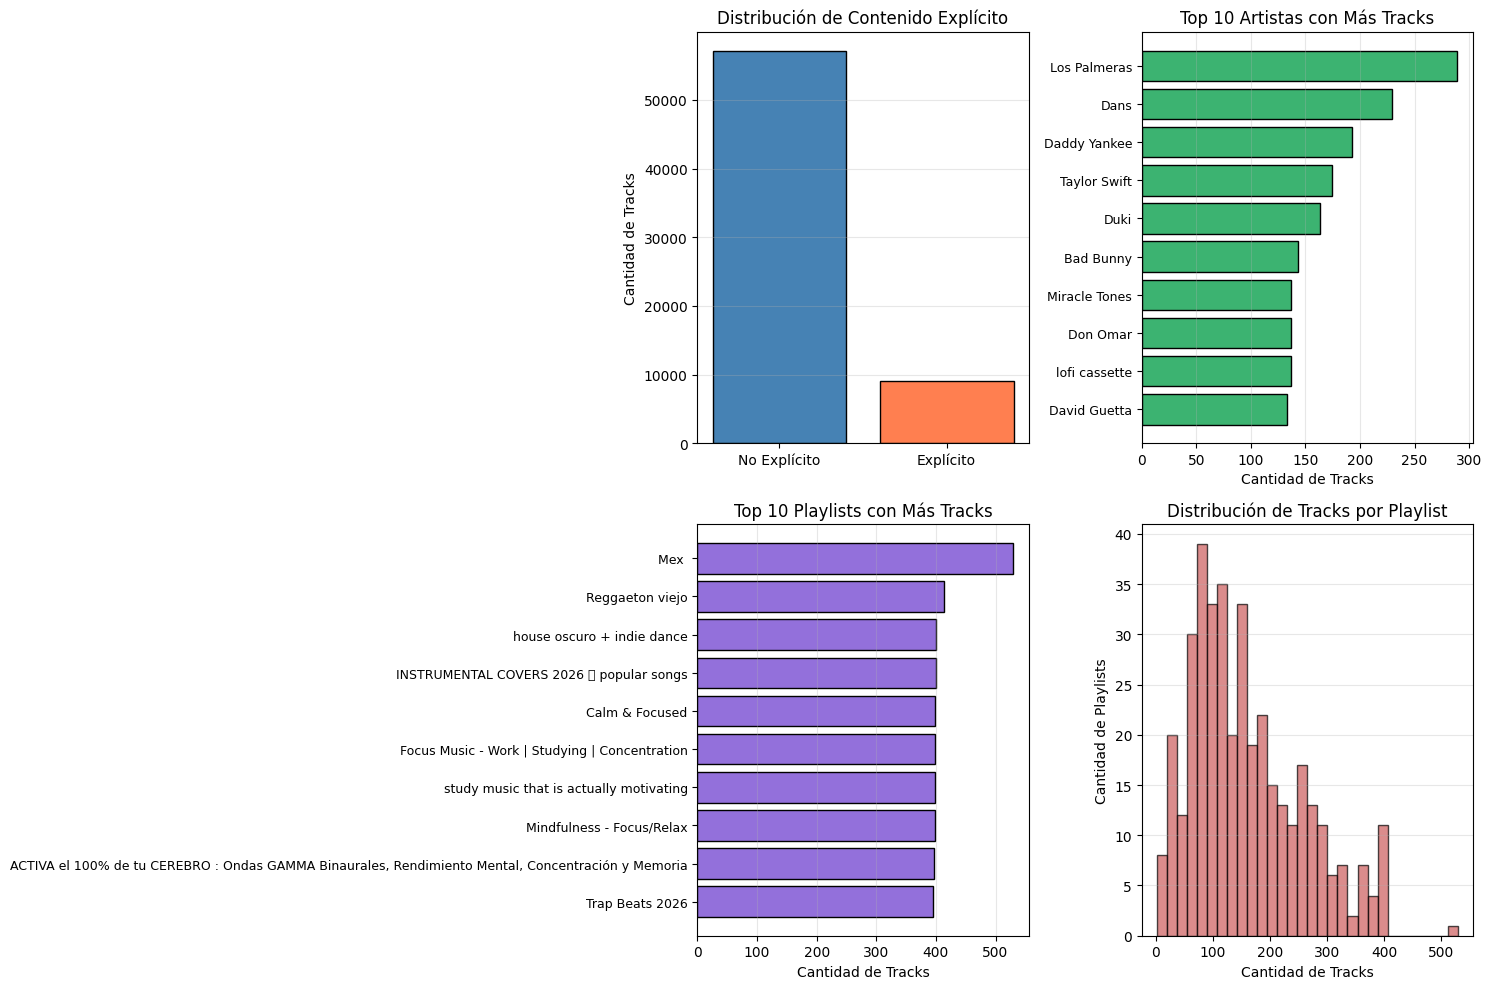

In [10]:
# Visualizaciones de variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Contenido explícito
explicit_counts = df['explicit'].value_counts()
axes[0, 0].bar(['No Explícito', 'Explícito'], explicit_counts.values, color=['steelblue', 'coral'], edgecolor='black')
axes[0, 0].set_ylabel('Cantidad de Tracks')
axes[0, 0].set_title('Distribución de Contenido Explícito')
axes[0, 0].grid(axis='y', alpha=0.3)

# Top 10 artistas
top_artists = df.groupby('artist_name').size().sort_values(ascending=False).head(10)
axes[0, 1].barh(range(len(top_artists)), top_artists.values, color='mediumseagreen', edgecolor='black')
axes[0, 1].set_yticks(range(len(top_artists)))
axes[0, 1].set_yticklabels(top_artists.index, fontsize=9)
axes[0, 1].set_xlabel('Cantidad de Tracks')
axes[0, 1].set_title('Top 10 Artistas con Más Tracks')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# Top 10 playlists
top_playlists = df.groupby('playlist_name').size().sort_values(ascending=False).head(10)
axes[1, 0].barh(range(len(top_playlists)), top_playlists.values, color='mediumpurple', edgecolor='black')
axes[1, 0].set_yticks(range(len(top_playlists)))
axes[1, 0].set_yticklabels(top_playlists.index, fontsize=9)
axes[1, 0].set_xlabel('Cantidad de Tracks')
axes[1, 0].set_title('Top 10 Playlists con Más Tracks')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Distribución de tracks por playlist (histograma)
tracks_per_playlist = df.groupby('playlist_id').size()
axes[1, 1].hist(tracks_per_playlist, bins=30, color='indianred', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Cantidad de Tracks')
axes[1, 1].set_ylabel('Cantidad de Playlists')
axes[1, 1].set_title('Distribución de Tracks por Playlist')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


#### 📅 Análisis Temporal


In [11]:
# Análisis temporal - fecha de adición a playlists
print("=" * 80)
print("ANÁLISIS TEMPORAL - FECHA DE ADICIÓN A PLAYLISTS")
print("=" * 80)

# Convertir added_at a datetime
df['added_at_dt'] = pd.to_datetime(df['added_at'])
df['added_year'] = df['added_at_dt'].dt.year
df['added_month'] = df['added_at_dt'].dt.month
df['added_day_of_week'] = df['added_at_dt'].dt.day_name()

print(f"\nRango de fechas de adición:")
print(f"Fecha más antigua: {df['added_at_dt'].min()}")
print(f"Fecha más reciente: {df['added_at_dt'].max()}")

# Distribución por año
print("\n" + "=" * 80)
print("DISTRIBUCIÓN POR AÑO DE ADICIÓN")
print("=" * 80)
print(df['added_year'].value_counts().sort_index())

# Distribución por mes
print("\n" + "=" * 80)
print("DISTRIBUCIÓN POR MES DE ADICIÓN")
print("=" * 80)
print(df['added_month'].value_counts().sort_index())

# Análisis de fechas de lanzamiento de álbumes (si existen)
print("\n" + "=" * 80)
print("ANÁLISIS DE FECHAS DE LANZAMIENTO DE ÁLBUMES")
print("=" * 80)
release_dates_null = df['album_release_date'].isnull().sum()
print(f"Álbumes sin fecha de lanzamiento: {release_dates_null:,} ({release_dates_null/len(df)*100:.2f}%)")

if release_dates_null < len(df):
    # Analizar los que sí tienen fecha
    df_with_release = df[df['album_release_date'].notna()].copy()
    print(f"\nÁlbumes con fecha de lanzamiento: {len(df_with_release):,}")
    print(f"Muestra de fechas de lanzamiento:")
    print(df_with_release['album_release_date'].head(10))


ANÁLISIS TEMPORAL - FECHA DE ADICIÓN A PLAYLISTS

Rango de fechas de adición:
Fecha más antigua: 2015-02-07 03:29:46+00:00
Fecha más reciente: 2026-02-24 14:20:01+00:00

DISTRIBUCIÓN POR AÑO DE ADICIÓN
added_year
2015.00    142
2016.00     72
2017.00    188
2018.00    243
2019.00     48
2020.00     47
2022.00    530
2023.00     17
2024.00     55
2025.00     92
2026.00    222
Name: count, dtype: int64

DISTRIBUCIÓN POR MES DE ADICIÓN
added_month
1.00     136
2.00     335
3.00      65
4.00      67
5.00      70
6.00      57
7.00     360
8.00     276
9.00     105
10.00     48
11.00     28
12.00    109
Name: count, dtype: int64

ANÁLISIS DE FECHAS DE LANZAMIENTO DE ÁLBUMES
Álbumes sin fecha de lanzamiento: 30 (0.05%)

Álbumes con fecha de lanzamiento: 66,126
Muestra de fechas de lanzamiento:
0    2026-02-06
1    2023-12-01
2    2025-03-14
3    2025-10-23
4    2026-01-16
5    2025-08-08
6    2025-05-23
7    2026-01-30
8    2024-11-08
9    2025-09-19
Name: album_release_date, dtype: object


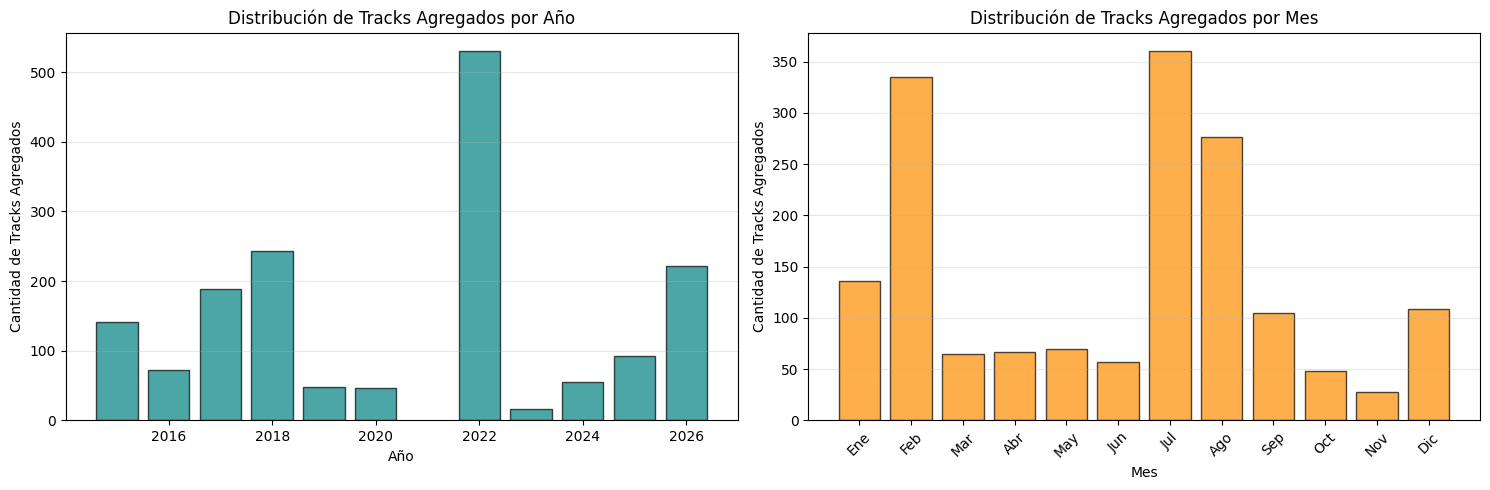

In [12]:
# Visualizaciones temporales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución por año
year_counts = df['added_year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad de Tracks Agregados')
axes[0].set_title('Distribución de Tracks Agregados por Año')
axes[0].grid(axis='y', alpha=0.3)

# Distribución por mes
month_counts = df['added_month'].value_counts().sort_index()
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
axes[1].bar(month_counts.index, month_counts.values, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad de Tracks Agregados')
axes[1].set_title('Distribución de Tracks Agregados por Mes')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


#### 🔗 Análisis de Correlaciones y Relaciones


CORRELACIÓN ENTRE VARIABLES NUMÉRICAS

Matriz de correlación:
                  track_popularity  duration_ms  duration_min
track_popularity              1.00         0.00          0.00
duration_ms                   0.00         1.00          1.00
duration_min                  0.00         1.00          1.00


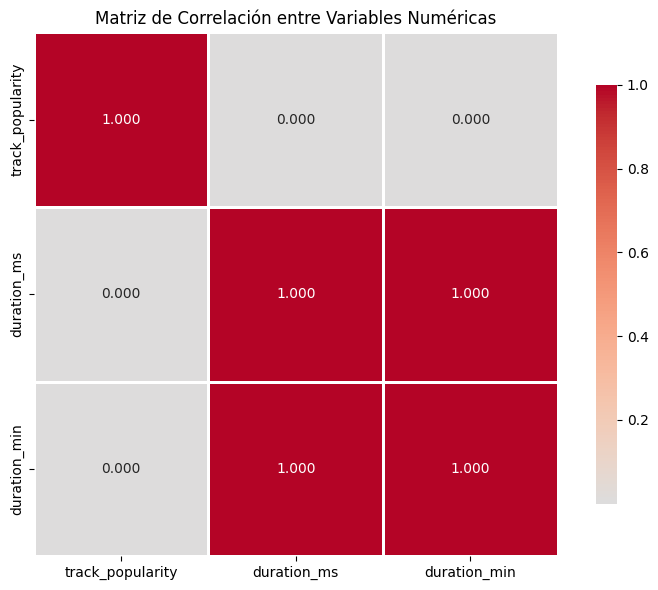


RELACIÓN ENTRE POPULARIDAD Y DURACIÓN
Correlación popularidad vs duración: 0.000


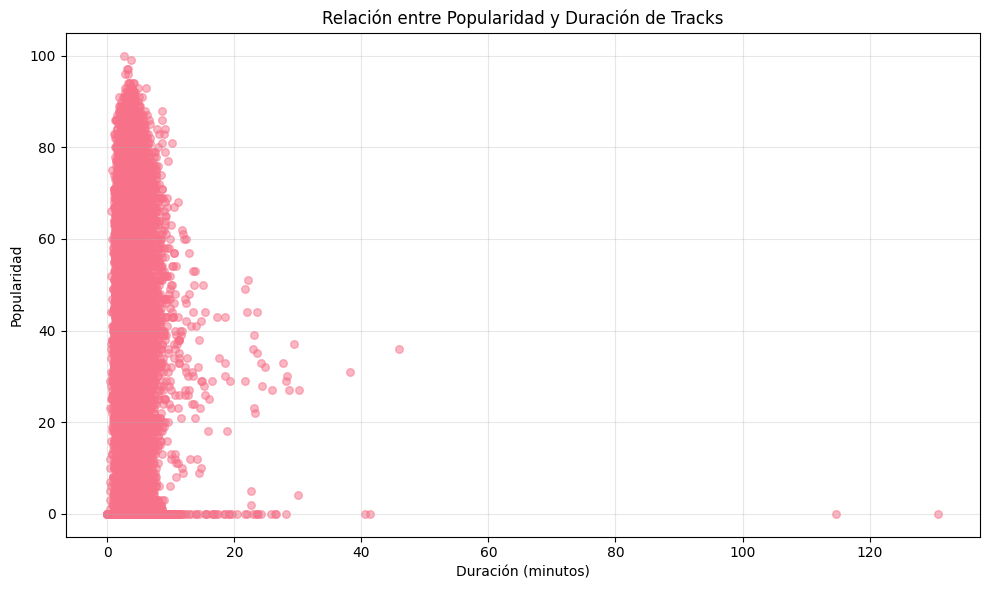

In [13]:
# Análisis de correlaciones entre variables numéricas

print("=" * 80)
print("CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")
print("=" * 80)

# Matriz de correlación
corr_cols = ['track_popularity', 'duration_ms', 'duration_min']
corr_matrix = df[corr_cols].corr()

print("\nMatriz de correlación:")
print(corr_matrix.round(3))

# Visualización de correlación
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title('Matriz de Correlación entre Variables Numéricas')
plt.tight_layout()
plt.show()

# Relación entre popularidad y duración
print("\n" + "=" * 80)
print("RELACIÓN ENTRE POPULARIDAD Y DURACIÓN")
print("=" * 80)
print(f"Correlación popularidad vs duración: {df['track_popularity'].corr(df['duration_min']):.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['duration_min'], df['track_popularity'], alpha=0.5, s=30)
ax.set_xlabel('Duración (minutos)')
ax.set_ylabel('Popularidad')
ax.set_title('Relación entre Popularidad y Duración de Tracks')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### 📊 Análisis de Popularidad por Categorías


In [14]:
# Análisis de popularidad por diferentes categorías
print("=" * 80)
print("ANÁLISIS DE POPULARIDAD POR CATEGORÍAS")
print("=" * 80)

# Popularidad por contenido explícito
print("\n--- Popularidad según Contenido Explícito ---")
popularity_explicit = df.groupby('explicit')['track_popularity'].agg(['mean', 'median', 'std', 'count'])
popularity_explicit.columns = ['Media', 'Mediana', 'Desv. Est.', 'Cantidad']
print(popularity_explicit.round(2))

# Top artistas por popularidad promedio
print("\n--- Top 10 Artistas por Popularidad Promedio (min 5 tracks) ---")
artist_pop = df.groupby('artist_name')['track_popularity'].agg(['mean', 'count']).reset_index()
artist_pop = artist_pop[artist_pop['count'] >= 5].sort_values('mean', ascending=False).head(10)
artist_pop.columns = ['Artista', 'Popularidad Promedio', 'Cantidad Tracks']
print(artist_pop.to_string(index=False))

# Top playlists por popularidad promedio
print("\n--- Popularidad Promedio por Playlist ---")
playlist_pop = df.groupby('playlist_name')['track_popularity'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
playlist_pop.columns = ['Media', 'Mediana', 'Desv. Est.', 'Cantidad Tracks']
print(playlist_pop.round(2))


ANÁLISIS DE POPULARIDAD POR CATEGORÍAS

--- Popularidad según Contenido Explícito ---
          Media  Mediana  Desv. Est.  Cantidad
explicit                                      
False     35.20    37.00       23.54     57056
True      43.94    50.00       26.51      9100

--- Top 10 Artistas por Popularidad Promedio (min 5 tracks) ---
      Artista  Popularidad Promedio  Cantidad Tracks
        sombr                 83.29                7
  Frank Ocean                 82.86                7
     Junior H                 82.00                9
  Olivia Dean                 81.67               18
 Benson Boone                 81.56                9
      HUNTR/X                 81.00                7
       Laufey                 79.17                6
   The Smiths                 79.00                7
Billie Eilish                 78.66               32
Chappell Roan                 77.90               10

--- Popularidad Promedio por Playlist ---
                                   

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 128151 (\N{GROWING HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127804 (\N{BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 129381

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 128760 (\N{FLYING SAUCER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127827 (\N{STRAWBERRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 128163 (\N{BOMB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarnin

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127927 (\N{SAXOPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127808 (\N{FOUR LEAF CLOVER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 129322 (\N{GRINNING FACE WITH ONE LARGE AND ONE SMALL EYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127996 (\N{EMOJI MODIFIER FITZPATRICK TYPE-3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv6

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127476 (\N{REGIONAL INDICATOR SYMBOL LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127474 (\N{REGIONAL INDICATOR SYMBOL LETTER M}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 127485 (\N{REGIONAL INDICATOR SYMBOL LETTER X}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/2723849273.py:44: UserWarning: Glyph 128509 (\N{STATUE OF LIBERTY}) missing from font(s) DejaVu Sans.
  plt.tight_l

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128151 (\N{GROWING HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127804 (\N{BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing f

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127939 (\N{RUNNER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129781 (\N{INDEX POINTING AT THE VIEWER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128760 (\N{FLYING SAUCER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: 

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127808 (\N{FOUR LEAF CLOVER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129322 (\N{GRINNING FACE WITH ONE LARGE AND ONE SMALL EYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127996 (\N{EMOJI MODIFIER FITZPATRICK TYPE-3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-package

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127476 (\N{REGIONAL INDICATOR SYMBOL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127474 (\N{REGIONAL INDICATOR SYMBOL LETTER M}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127485 (\N{REGIONAL INDICATOR SYMBOL LETTER X}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/

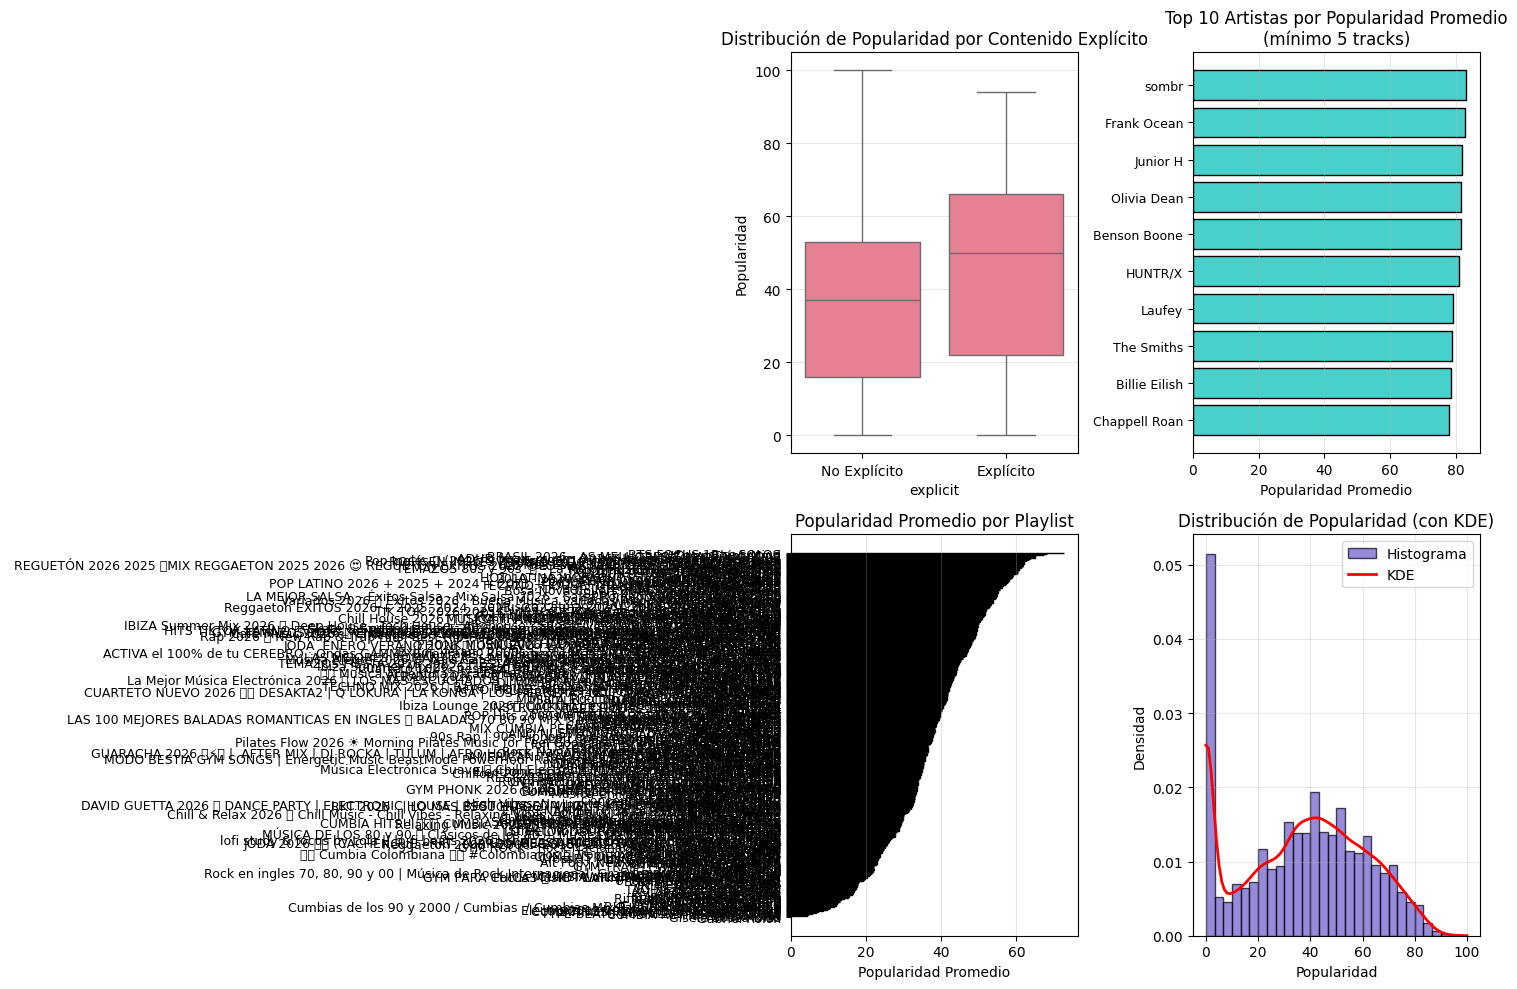

In [15]:
# Visualización de popularidad por categorías
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplot: Popularidad por contenido explícito
df_boxplot = df[['track_popularity', 'explicit']].copy()
df_boxplot['explicit'] = df_boxplot['explicit'].map({True: 'Explícito', False: 'No Explícito'})
sns.boxplot(data=df_boxplot, x='explicit', y='track_popularity', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Popularidad por Contenido Explícito')
axes[0, 0].set_ylabel('Popularidad')
axes[0, 0].grid(axis='y', alpha=0.3)

# Top 10 artistas por popularidad promedio (min 5 tracks)
artist_pop = df.groupby('artist_name')['track_popularity'].agg(['mean', 'count']).reset_index()
artist_pop = artist_pop[artist_pop['count'] >= 5].sort_values('mean', ascending=False).head(10)
axes[0, 1].barh(range(len(artist_pop)), artist_pop['mean'].values, color='mediumturquoise', edgecolor='black')
axes[0, 1].set_yticks(range(len(artist_pop)))
axes[0, 1].set_yticklabels(artist_pop['artist_name'], fontsize=9)
axes[0, 1].set_xlabel('Popularidad Promedio')
axes[0, 1].set_title('Top 10 Artistas por Popularidad Promedio\n(mínimo 5 tracks)')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# Popularidad promedio por playlist
playlist_pop = df.groupby('playlist_name')['track_popularity'].mean().sort_values(ascending=False)
axes[1, 0].barh(range(len(playlist_pop)), playlist_pop.values, color='lightcoral', edgecolor='black')
axes[1, 0].set_yticks(range(len(playlist_pop)))
axes[1, 0].set_yticklabels(playlist_pop.index, fontsize=9)
axes[1, 0].set_xlabel('Popularidad Promedio')
axes[1, 0].set_title('Popularidad Promedio por Playlist')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Distribución de popularidad general (histograma con KDE)
axes[1, 1].hist(df['track_popularity'], bins=30, density=True, alpha=0.7, color='slateblue', edgecolor='black', label='Histograma')
kde = stats.gaussian_kde(df['track_popularity'].dropna())
x_range = np.linspace(df['track_popularity'].min(), df['track_popularity'].max(), 100)
axes[1, 1].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
axes[1, 1].set_xlabel('Popularidad')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Distribución de Popularidad (con KDE)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### 🎵 Análisis de Diversidad y Distribución


In [16]:
# Análisis de diversidad en playlists
print("=" * 80)
print("ANÁLISIS DE DIVERSIDAD EN PLAYLISTS")
print("=" * 80)

diversidad_playlists = df.groupby('playlist_id').agg({
    'track_id': 'count',
    'artist_id': 'nunique',
    'album_id': 'nunique'
}).reset_index()
diversidad_playlists.columns = ['playlist_id', 'total_tracks', 'artistas_unicos', 'albumes_unicos']
diversidad_playlists = diversidad_playlists.merge(
    df[['playlist_id', 'playlist_name']].drop_duplicates(), 
    on='playlist_id'
)
diversidad_playlists['diversidad_artistas'] = diversidad_playlists['artistas_unicos'] / diversidad_playlists['total_tracks']
diversidad_playlists['diversidad_albumes'] = diversidad_playlists['albumes_unicos'] / diversidad_playlists['total_tracks']

print("\nDiversidad por playlist (ordenado por diversidad de artistas):")
diversidad_display = diversidad_playlists[['playlist_name', 'total_tracks', 'artistas_unicos', 
                                           'albumes_unicos', 'diversidad_artistas', 'diversidad_albumes']].copy()
diversidad_display.columns = ['Playlist', 'Total Tracks', 'Artistas Únicos', 
                              'Álbumes Únicos', 'Ratio Artistas', 'Ratio Álbumes']
diversidad_display = diversidad_display.sort_values('Ratio Artistas', ascending=False)
print(diversidad_display.to_string(index=False))

# Promedio de tracks por artista
print("\n" + "=" * 80)
print("ESTADÍSTICAS DE DISTRIBUCIÓN")
print("=" * 80)
tracks_per_artist = df.groupby('artist_id').size()
print(f"\nTracks por artista:")
print(f"  Promedio: {tracks_per_artist.mean():.2f}")
print(f"  Mediana: {tracks_per_artist.median():.2f}")
print(f"  Máximo: {tracks_per_artist.max()}")
print(f"  Artistas con 1 track: {(tracks_per_artist == 1).sum()} ({(tracks_per_artist == 1).sum()/len(tracks_per_artist)*100:.2f}%)")
print(f"  Artistas con más de 10 tracks: {(tracks_per_artist > 10).sum()} ({(tracks_per_artist > 10).sum()/len(tracks_per_artist)*100:.2f}%)")


ANÁLISIS DE DIVERSIDAD EN PLAYLISTS

Diversidad por playlist (ordenado por diversidad de artistas):
                                                                                            Playlist  Total Tracks  Artistas Únicos  Álbumes Únicos  Ratio Artistas  Ratio Álbumes
                                                                     Sport Motivation Music 2026 💪🏋️             5                5               5            1.00           1.00
                                                                            Música electrónica suave            11               11              11            1.00           1.00
                                                                                TEMAZOS CHILL OUT 🌅              2                2               2            1.00           1.00
                                                                                   Indie pop rocks 🎸           169              165             168            0.98           0.99
     

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127749 (\N{SUNRISE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 129397 (\N{OVERHEATED FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: G

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 128153 (\N{BLUE HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 128141 (\N{RING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127827 (\N{STRAWBERRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127804 (\N{BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127996 (\N

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127476 (\N{REGIONAL INDICATOR SYMBOL LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127864 (\N{COCKTAIL GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127817 (\N{WATERMELON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127474 (\N{REGIONAL INDICATOR SYMBOL LETTER M}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv69

/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 128509 (\N{STATUE OF LIBERTY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 128091 (\N{PURSE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarning: Glyph 127929 (\N{MUSICAL KEYBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6l/76fphv690tn5bmy85_jtkgr00000gn/T/ipykernel_29859/355514515.py:23: UserWarn

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127749 (\N{SUNRISE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129397 (\N{OVERHEATED

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128131 (\N{DANCER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128378 (\N{MAN DANCING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129705 (\N{MIRROR BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128132 (\N{LIPSTICK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128133 (\N{NAIL POLISH})

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128141 (\N{RING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127827 (\N{STRAWBERRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127804 (\N{BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127996 (\N{EMOJI MODIFIER FITZP

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127476 (\N{REGIONAL INDICATOR SYMBOL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127864 (\N{COCKTAIL GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127817 (\N{WATERMELON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabt

/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128139 (\N{KISS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129344 (\N{WILTED FLOWER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128227 (\N{CHEERING MEGAPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nicoguisande/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129514 

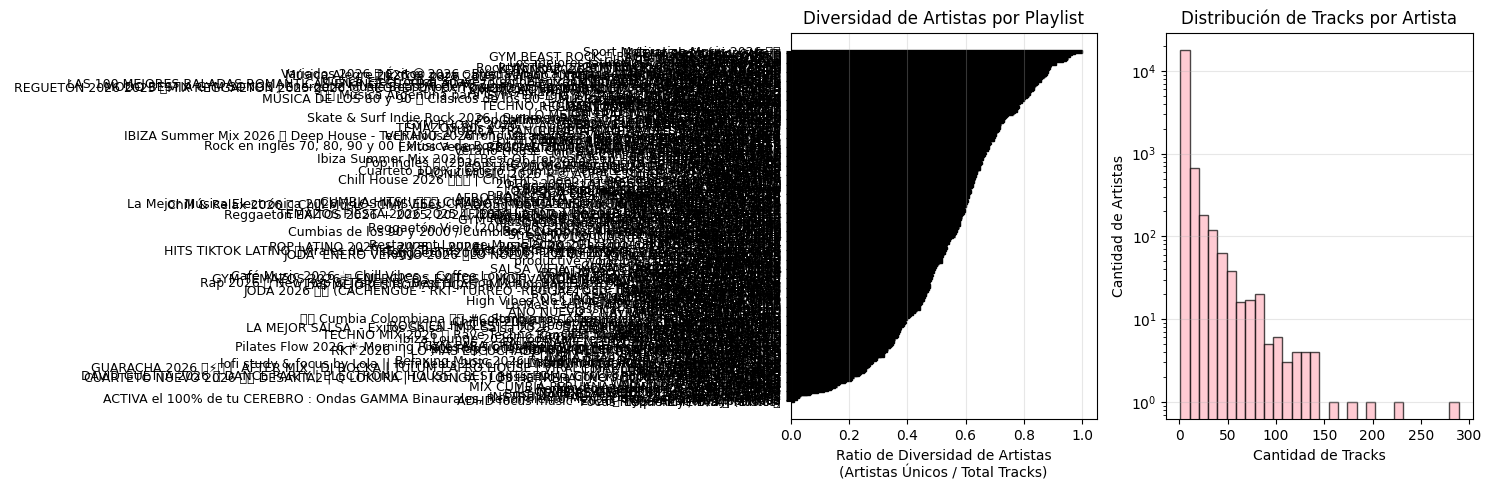

In [17]:
# Visualización de diversidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Diversidad de artistas por playlist
diversidad_display_plot = diversidad_playlists.sort_values('diversidad_artistas', ascending=False)
axes[0].barh(range(len(diversidad_display_plot)), diversidad_display_plot['diversidad_artistas'].values, 
             color='mediumaquamarine', edgecolor='black')
axes[0].set_yticks(range(len(diversidad_display_plot)))
axes[0].set_yticklabels(diversidad_display_plot['playlist_name'], fontsize=9)
axes[0].set_xlabel('Ratio de Diversidad de Artistas\n(Artistas Únicos / Total Tracks)')
axes[0].set_title('Diversidad de Artistas por Playlist')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Distribución de tracks por artista (histograma)
axes[1].hist(tracks_per_artist, bins=30, color='lightpink', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Cantidad de Tracks')
axes[1].set_ylabel('Cantidad de Artistas')
axes[1].set_title('Distribución de Tracks por Artista')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_yscale('log')  # Escala logarítmica para mejor visualización

plt.tight_layout()
plt.show()


#### ⏱️ Análisis de Duración por Categorías


In [18]:
# Análisis de duración por diferentes categorías (excluyendo outliers)
df_duration_clean = df[(df['duration_min'] > 0.1) & (df['duration_min'] < 15)].copy()

print("=" * 80)
print("ANÁLISIS DE DURACIÓN POR CATEGORÍAS")
print("=" * 80)

# Duración por contenido explícito
print("\n--- Duración según Contenido Explícito ---")
duration_explicit = df_duration_clean.groupby('explicit')['duration_min'].agg(['mean', 'median', 'std', 'count'])
duration_explicit.columns = ['Media (min)', 'Mediana (min)', 'Desv. Est.', 'Cantidad']
print(duration_explicit.round(2))

# Top artistas por duración promedio
print("\n--- Top 10 Artistas por Duración Promedio (min 5 tracks) ---")
artist_duration = df_duration_clean.groupby('artist_name')['duration_min'].agg(['mean', 'count']).reset_index()
artist_duration = artist_duration[artist_duration['count'] >= 5].sort_values('mean', ascending=False).head(10)
artist_duration.columns = ['Artista', 'Duración Promedio (min)', 'Cantidad Tracks']
print(artist_duration.to_string(index=False))

# Duración promedio por playlist
print("\n--- Duración Promedio por Playlist ---")
playlist_duration = df_duration_clean.groupby('playlist_name')['duration_min'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
playlist_duration.columns = ['Media (min)', 'Mediana (min)', 'Desv. Est.', 'Cantidad Tracks']
print(playlist_duration.round(2))


ANÁLISIS DE DURACIÓN POR CATEGORÍAS

--- Duración según Contenido Explícito ---
          Media (min)  Mediana (min)  Desv. Est.  Cantidad
explicit                                                  
False            3.36           3.24        1.13     56985
True             3.30           3.19        1.03      9096

--- Top 10 Artistas por Duración Promedio (min 5 tracks) ---
                  Artista  Duración Promedio (min)  Cantidad Tracks
      Tropitango Bailable                    12.62               13
     Free Cover Venezuela                     8.83                8
            David Parsons                     8.00                6
               Aphex Twin                     7.32                5
           Antonín Dvořák                     7.15               18
             Son del Duke                     7.11               13
Azucena Calvay y Orquesta                     7.04                5
                Kino Todo                     6.58                6
          

#### 📆 Análisis de Fechas de Lanzamiento de Álbumes


In [19]:
# Análisis profundo de fechas de lanzamiento
print("=" * 80)
print("ANÁLISIS DE FECHAS DE LANZAMIENTO DE ÁLBUMES")
print("=" * 80)

# Intentar parsear fechas de lanzamiento (pueden tener diferentes formatos)
def parse_release_date(date_str):
    """Intenta parsear fechas en diferentes formatos de Spotify"""
    if pd.isna(date_str):
        return None
    try:
        # Formato YYYY-MM-DD
        if len(str(date_str)) == 10:
            return pd.to_datetime(date_str, format='%Y-%m-%d')
        # Formato YYYY-MM
        elif len(str(date_str)) == 7:
            return pd.to_datetime(date_str + '-01', format='%Y-%m-%d')
        # Formato YYYY
        elif len(str(date_str)) == 4:
            return pd.to_datetime(str(date_str) + '-01-01', format='%Y-%m-%d')
        else:
            return pd.to_datetime(date_str, errors='coerce')
    except:
        return None

df['album_release_date_parsed'] = df['album_release_date'].apply(parse_release_date)
df['album_release_year'] = df['album_release_date_parsed'].dt.year
df['album_release_month'] = df['album_release_date_parsed'].dt.month
df['years_since_release'] = (pd.Timestamp.now() - df['album_release_date_parsed']).dt.days / 365.25

# Estadísticas de fechas de lanzamiento
df_with_release = df[df['album_release_date_parsed'].notna()].copy()
print(f"\nÁlbumes con fecha de lanzamiento válida: {len(df_with_release):,} ({len(df_with_release)/len(df)*100:.2f}%)")
print(f"\nRango de años de lanzamiento: {df_with_release['album_release_year'].min():.0f} - {df_with_release['album_release_year'].max():.0f}")
print(f"Año promedio de lanzamiento: {df_with_release['album_release_year'].mean():.1f}")
print(f"Antigüedad promedio: {df_with_release['years_since_release'].mean():.1f} años")

# Popularidad por año de lanzamiento
print("\n" + "=" * 80)
print("POPULARIDAD POR AÑO DE LANZAMIENTO")
print("=" * 80)
popularity_by_year = df_with_release.groupby('album_release_year')['track_popularity'].agg(['mean', 'median', 'count']).reset_index()
popularity_by_year = popularity_by_year[popularity_by_year['count'] >= 5].sort_values('album_release_year')  # Solo años con al menos 5 tracks
popularity_by_year.columns = ['Año', 'Popularidad Media', 'Popularidad Mediana', 'Cantidad Tracks']
print(popularity_by_year.tail(15).to_string(index=False))  # Últimos 15 años


ANÁLISIS DE FECHAS DE LANZAMIENTO DE ÁLBUMES



Álbumes con fecha de lanzamiento válida: 66,121 (99.95%)

Rango de años de lanzamiento: 1931 - 2026
Año promedio de lanzamiento: 2016.9
Antigüedad promedio: 8.8 años

POPULARIDAD POR AÑO DE LANZAMIENTO
    Año  Popularidad Media  Popularidad Mediana  Cantidad Tracks
2012.00              36.38                39.00             1056
2013.00              34.03                38.00             1005
2014.00              31.00                31.00             1432
2015.00              31.48                33.00             1640
2016.00              35.35                40.00             1750
2017.00              36.07                41.00             1988
2018.00              37.06                42.00             2219
2019.00              37.67                42.00             2549
2020.00              36.28                41.00             3032
2021.00              34.89                38.00             3547
2022.00              35.15                38.00             3901
2023.00          

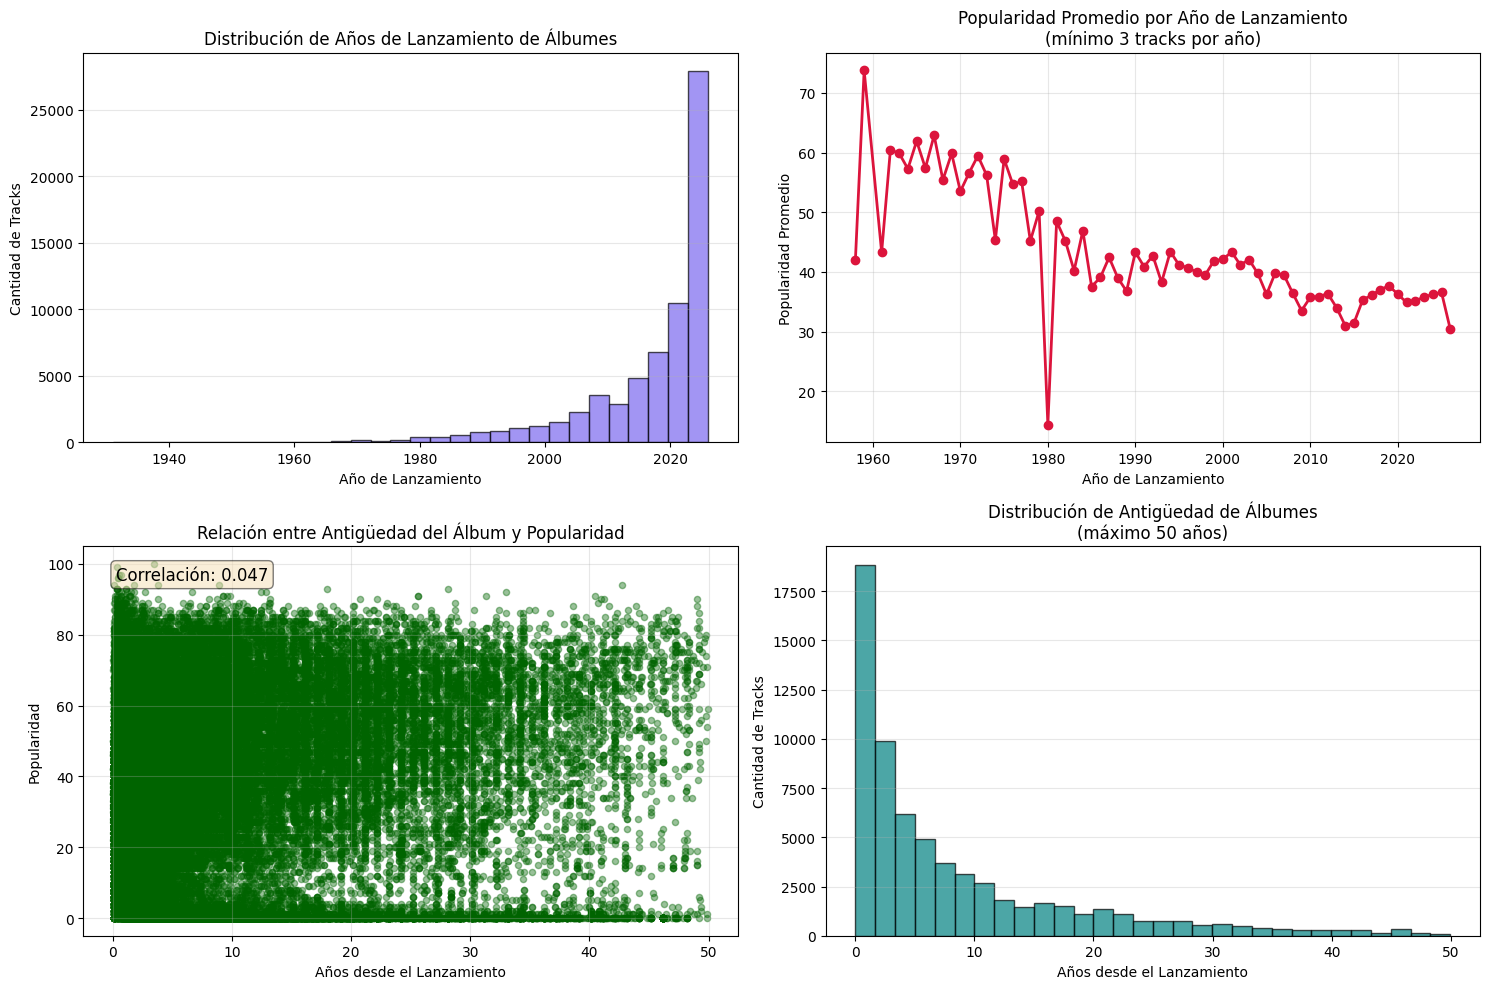

In [20]:
# Visualizaciones de fechas de lanzamiento
if len(df_with_release) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Distribución de años de lanzamiento
    axes[0, 0].hist(df_with_release['album_release_year'], bins=30, color='mediumslateblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Año de Lanzamiento')
    axes[0, 0].set_ylabel('Cantidad de Tracks')
    axes[0, 0].set_title('Distribución de Años de Lanzamiento de Álbumes')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Popularidad promedio por año de lanzamiento
    popularity_by_year_plot = df_with_release.groupby('album_release_year')['track_popularity'].agg(['mean', 'count']).reset_index()
    popularity_by_year_plot = popularity_by_year_plot[popularity_by_year_plot['count'] >= 3]  # Mínimo 3 tracks
    axes[0, 1].plot(popularity_by_year_plot['album_release_year'], popularity_by_year_plot['mean'], 
                    marker='o', linewidth=2, markersize=6, color='crimson')
    axes[0, 1].set_xlabel('Año de Lanzamiento')
    axes[0, 1].set_ylabel('Popularidad Promedio')
    axes[0, 1].set_title('Popularidad Promedio por Año de Lanzamiento\n(mínimo 3 tracks por año)')
    axes[0, 1].grid(alpha=0.3)
    
    # Relación entre antigüedad y popularidad
    df_with_release_clean = df_with_release[df_with_release['years_since_release'] <= 50].copy()  # Filtrar valores extremos
    axes[1, 0].scatter(df_with_release_clean['years_since_release'], df_with_release_clean['track_popularity'], 
                       alpha=0.4, s=20, color='darkgreen')
    axes[1, 0].set_xlabel('Años desde el Lanzamiento')
    axes[1, 0].set_ylabel('Popularidad')
    axes[1, 0].set_title('Relación entre Antigüedad del Álbum y Popularidad')
    axes[1, 0].grid(alpha=0.3)
    
    # Correlación antigüedad-popularidad
    corr_age_pop = df_with_release_clean['years_since_release'].corr(df_with_release_clean['track_popularity'])
    axes[1, 0].text(0.05, 0.95, f'Correlación: {corr_age_pop:.3f}', 
                    transform=axes[1, 0].transAxes, fontsize=12, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Distribución de antigüedad
    axes[1, 1].hist(df_with_release_clean['years_since_release'], bins=30, color='teal', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Años desde el Lanzamiento')
    axes[1, 1].set_ylabel('Cantidad de Tracks')
    axes[1, 1].set_title('Distribución de Antigüedad de Álbumes\n(máximo 50 años)')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


#### ⚠️ Análisis de Outliers y Valores Atípicos

In [21]:
# Detección de outliers usando método IQR
print("=" * 80)
print("ANÁLISIS DE OUTLIERS (Método IQR)")
print("=" * 80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Outliers en popularidad
outliers_pop, lower_pop, upper_pop = detect_outliers_iqr(df, 'track_popularity')
print(f"\n--- Popularidad ---")
print(f"Límite inferior: {lower_pop:.2f}")
print(f"Límite superior: {upper_pop:.2f}")
print(f"Outliers encontrados: {len(outliers_pop):,} ({len(outliers_pop)/len(df)*100:.2f}%)")
if len(outliers_pop) > 0:
    print(f"\nTop 5 tracks con mayor popularidad:")
    print(outliers_pop.nlargest(5, 'track_popularity')[['track_name', 'artist_name', 'track_popularity']].to_string(index=False))

# Outliers en duración (excluyendo valores 0 o muy pequeños)
df_duration_valid = df[df['duration_min'] > 0.1].copy()
outliers_dur, lower_dur, upper_dur = detect_outliers_iqr(df_duration_valid, 'duration_min')
print(f"\n--- Duración (excluyendo tracks muy cortos) ---")
print(f"Límite inferior: {lower_dur:.2f} minutos")
print(f"Límite superior: {upper_dur:.2f} minutos")
print(f"Outliers encontrados: {len(outliers_dur):,} ({len(outliers_dur)/len(df_duration_valid)*100:.2f}%)")
if len(outliers_dur) > 0:
    print(f"\nTop 5 tracks con mayor duración:")
    print(outliers_dur.nlargest(5, 'duration_min')[['track_name', 'artist_name', 'duration_min']].to_string(index=False))

# Tracks con duración 0 o muy corta
print(f"\n--- Tracks con duración anómala ---")
tracks_cortos = df[df['duration_min'] <= 0.1]
print(f"Tracks con duración ≤ 0.1 minutos: {len(tracks_cortos):,} ({len(tracks_cortos)/len(df)*100:.2f}%)")


ANÁLISIS DE OUTLIERS (Método IQR)

--- Popularidad ---
Límite inferior: -40.00
Límite superior: 112.00
Outliers encontrados: 0 (0.00%)

--- Duración (excluyendo tracks muy cortos) ---
Límite inferior: 0.72 minutos
Límite superior: 5.77 minutos
Outliers encontrados: 2,066 (3.12%)

Top 5 tracks con mayor duración:
                                                                         track_name        artist_name  duration_min
Cómo Amarse a uno Mismo y Tener Buena Salud Mental: Hábitos de Vida - Gabriel Rolón               None        130.83
                                         DH 07 – 08 – 2023 ENTREVISTA GABRIEL ROLON               None        114.64
                                                        Enganchado Retro 80 - Remix DJ Luc14no Antileo         45.85
                                                                   Versions, Vol. 2             NPLGNN         41.38
     Gabriel Rolón: "Es un momento para apropiarse más que nunca de nuestro tiempo"               Non

#### 🎯 Definición del Target Variable para Machine Learning


In [22]:
# Definición del target variable: popularidad alta vs baja
print("=" * 80)
print("DEFINICIÓN DEL TARGET VARIABLE")
print("=" * 80)

# Análisis de distribución de popularidad para definir umbral
print("\nDistribución de popularidad (percentiles):")
percentiles = [0, 10, 20, 25, 30, 40, 50, 60, 70, 75, 80, 90, 100]
pop_percentiles = np.percentile(df['track_popularity'], percentiles)
percentile_df = pd.DataFrame({
    'Percentil': [f'{p}%' for p in percentiles],
    'Popularidad': pop_percentiles.astype(int)
})
print(percentile_df.to_string(index=False))

# Definición de umbrales comparativos
umbral_50 = df['track_popularity'].median()
umbral_60 = np.percentile(df['track_popularity'], 60)
umbral_70 = np.percentile(df['track_popularity'], 70)

print(f"\nAlternativa 50%: {umbral_50:.0f}")
print(f"Alternativa 60%: {umbral_60:.0f}")
print(f"Alternativa 70% (target principal): {umbral_70:.0f}")

# Target principal (canónico): P70
target_threshold = umbral_70
df['popular_high'] = (df['track_popularity'] >= target_threshold).astype(int)

# Targets comparativos para análisis
df['popular_high_p50'] = (df['track_popularity'] >= umbral_50).astype(int)
df['popular_high_p60'] = (df['track_popularity'] >= umbral_60).astype(int)

print("\n" + "=" * 80)
print("DISTRIBUCIÓN DEL TARGET PRINCIPAL (popular_high - P70)")
print("=" * 80)
target_dist = df['popular_high'].value_counts().sort_index()
target_dist_pct = df['popular_high'].value_counts(normalize=True).sort_index() * 100
print(f"\nNo Popular (0): {target_dist[0]:,} tracks ({target_dist_pct[0]:.2f}%)")
print(f"Popular (1): {target_dist[1]:,} tracks ({target_dist_pct[1]:.2f}%)")
print(f"Balance de clases: {min(target_dist_pct):.2f}% / {max(target_dist_pct):.2f}%")
print(f"Ratio: {min(target_dist) / max(target_dist):.3f}")

# Análisis de umbrales alternativos
print("\n--- Análisis de Umbrales Alternativos ---")
for threshold_name, col_name in [
    ('Mediana 50', 'popular_high_p50'),
    ('Percentil 60', 'popular_high_p60'),
    ('Percentil 70 (principal)', 'popular_high')
]:
    dist = df[col_name].value_counts().sort_index()
    dist_pct = df[col_name].value_counts(normalize=True).sort_index() * 100
    ratio = min(dist) / max(dist)
    print(f"{threshold_name}: Popular={dist.get(1, 0):,} ({dist_pct.get(1, 0):.2f}%), Ratio={ratio:.3f}")


DEFINICIÓN DEL TARGET VARIABLE

Distribución de popularidad (percentiles):
Percentil  Popularidad
       0%            0
      10%            0
      20%            9
      25%           17
      30%           22
      40%           32
      50%           38
      60%           45
      70%           51
      75%           55
      80%           59
      90%           68
     100%          100

Alternativa 50%: 38
Alternativa 60%: 45
Alternativa 70% (target principal): 51

DISTRIBUCIÓN DEL TARGET PRINCIPAL (popular_high - P70)

No Popular (0): 45,560 tracks (68.87%)
Popular (1): 20,596 tracks (31.13%)
Balance de clases: 31.13% / 68.87%
Ratio: 0.452

--- Análisis de Umbrales Alternativos ---
Mediana 50: Popular=33,958 (51.33%), Ratio=0.948
Percentil 60: Popular=26,557 (40.14%), Ratio=0.671
Percentil 70 (principal): Popular=20,596 (31.13%), Ratio=0.452


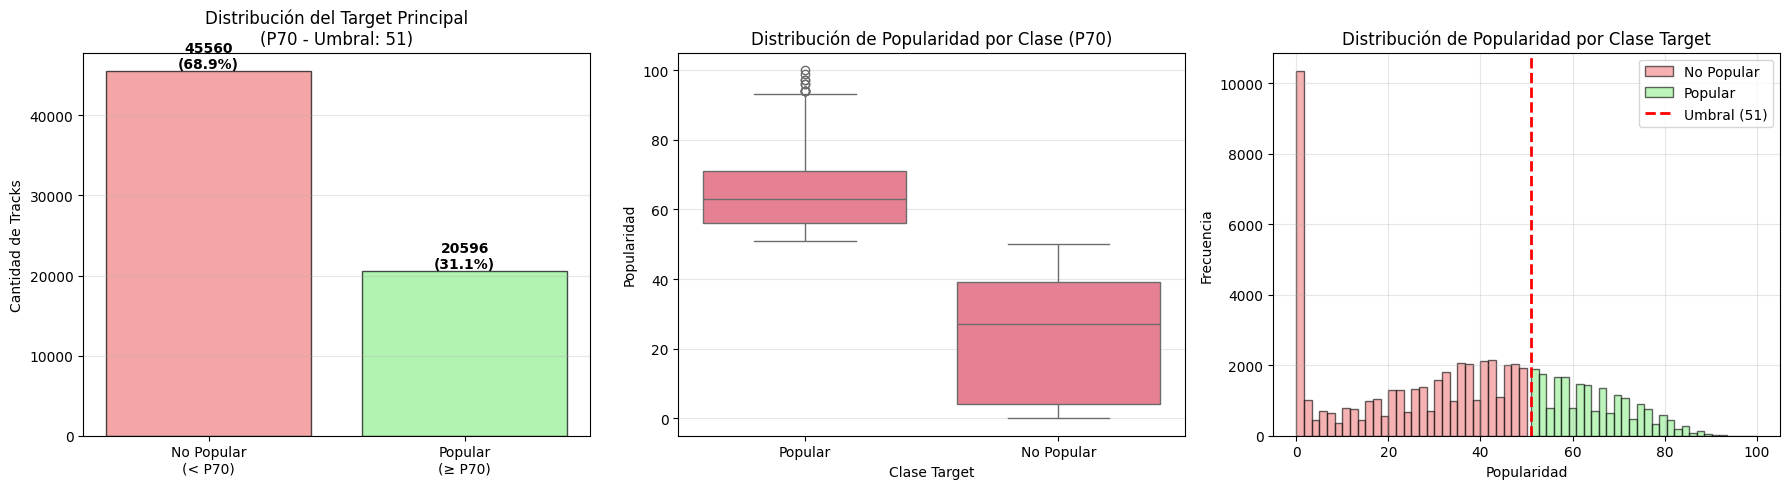

In [23]:
# Visualización del target variable principal (P70)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución del target principal
target_dist = df['popular_high'].value_counts().sort_index()
axes[0].bar(['No Popular\n(< P70)', 'Popular\n(≥ P70)'], target_dist.values,
            color=['lightcoral', 'lightgreen'], edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Cantidad de Tracks')
axes[0].set_title(f'Distribución del Target Principal\n(P70 - Umbral: {target_threshold:.0f})')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(target_dist.values):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

# Distribución de popularidad por clase principal
df['target_label'] = df['popular_high'].map({0: 'No Popular', 1: 'Popular'})
sns.boxplot(data=df, x='target_label', y='track_popularity', ax=axes[1])
axes[1].set_ylabel('Popularidad')
axes[1].set_xlabel('Clase Target')
axes[1].set_title('Distribución de Popularidad por Clase (P70)')
axes[1].grid(axis='y', alpha=0.3)

# Histograma comparativo
axes[2].hist(df[df['popular_high'] == 0]['track_popularity'], bins=30, alpha=0.6,
             label='No Popular', color='lightcoral', edgecolor='black')
axes[2].hist(df[df['popular_high'] == 1]['track_popularity'], bins=30, alpha=0.6,
             label='Popular', color='lightgreen', edgecolor='black')
axes[2].axvline(target_threshold, color='red', linestyle='--', linewidth=2, label=f'Umbral ({target_threshold:.0f})')
axes[2].set_xlabel('Popularidad')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de Popularidad por Clase Target')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### 📝 Análisis de Features Potenciales


In [24]:
# ============================================================
# Normalización de targets para análisis comparativo (P50 vs P70)
# ============================================================

# P50 (mediana) como comparativo
df["target_p50"] = df["popular_high_p50"].astype(int)

# P70 como target principal
df["target_p70"] = df["popular_high"].astype(int)

print("Distribución target P50:", df["target_p50"].value_counts(normalize=True).round(3).to_dict())
print("Distribución target P70:", df["target_p70"].value_counts(normalize=True).round(3).to_dict())


Distribución target P50: {1: 0.513, 0: 0.487}
Distribución target P70: {0: 0.689, 1: 0.311}


In [25]:
# Análisis de características potenciales derivadas
print("=" * 80)
print("ANÁLISIS DE FEATURES POTENCIALES")
print("=" * 80)

# Longitud de nombres (podrían ser features de texto)
df['track_name_length'] = df['track_name'].str.len()
df['artist_name_length'] = df['artist_name'].fillna('').str.len()
df['album_name_length'] = df['album_name'].str.len()

# Características temporales
df['added_month_sin'] = np.sin(2 * np.pi * df['added_month'] / 12)  # Ciclicidad mensual
df['added_month_cos'] = np.cos(2 * np.pi * df['added_month'] / 12)
df['added_day_of_week_num'] = df['added_at_dt'].dt.dayofweek

# Features agregadas por artista y playlist
artist_stats = df.groupby('artist_id').agg({
    'track_popularity': ['mean', 'std', 'count'],
    'duration_min': 'mean'
}).reset_index()
artist_stats.columns = ['artist_id', 'artist_avg_popularity', 'artist_popularity_std', 'artist_track_count', 'artist_avg_duration']
df = df.merge(artist_stats, on='artist_id', how='left')

playlist_stats = df.groupby('playlist_id').agg({
    'track_popularity': ['mean', 'std', 'count'],
    'duration_min': 'mean'
}).reset_index()
playlist_stats.columns = ['playlist_id', 'playlist_avg_popularity', 'playlist_popularity_std', 'playlist_track_count', 'playlist_avg_duration']
df = df.merge(playlist_stats, on='playlist_id', how='left')

# Resumen de nuevas features
print("\n--- Nuevas Features Generadas ---")
new_features = [
    'track_name_length', 'artist_name_length', 'album_name_length',
    'added_month_sin', 'added_month_cos', 'added_day_of_week_num',
    'artist_avg_popularity', 'artist_popularity_std', 'artist_track_count', 'artist_avg_duration',
    'playlist_avg_popularity', 'playlist_popularity_std', 'playlist_track_count', 'playlist_avg_duration',
    'album_release_year', 'years_since_release'
]

print(f"Total de features potenciales: {len(new_features)}")
print("\nEstadísticas descriptivas:")
print(df[new_features].describe().T.round(2))


ANÁLISIS DE FEATURES POTENCIALES



--- Nuevas Features Generadas ---
Total de features potenciales: 16

Estadísticas descriptivas:
                           count    mean    std     min     25%     50%  \
track_name_length       66156.00   16.67  12.34    0.00    9.00   13.00   
artist_name_length      66156.00   10.44   4.80    0.00    7.00   10.00   
album_name_length       66156.00   16.97  11.97    0.00    9.00   14.00   
added_month_sin          1656.00   -0.04   0.72   -1.00   -0.87   -0.00   
added_month_cos          1656.00   -0.10   0.69   -1.00   -0.87   -0.50   
added_day_of_week_num    1656.00    1.96   1.94    0.00    1.00    1.00   
artist_avg_popularity   66156.00   36.40  18.30    0.00   23.59   37.56   
artist_popularity_std   55123.00   15.29  10.25    0.00    6.23   14.13   
artist_track_count      66156.00   24.11  38.23    1.00    2.00    9.00   
artist_avg_duration     66156.00    3.38   1.24    0.39    2.75    3.30   
playlist_avg_popularity 62111.00   35.68  13.38    0.00   25.10   35.81   
pla

TOP FEATURES (P50) por AUC univariado


,feature,missing_rate,mean_0,mean_1,diff_means,cohen_d,corr_pointbiserial,auc_univariate,nunique
6,artist_avg_popularity,0.00,23.72,48.43,24.71,1.83,0.67,0.90,2084
10,playlist_avg_popularity,0.06,28.80,42.51,13.71,1.19,0.51,0.79,387
8,artist_track_count,0.00,21.82,26.29,4.47,0.12,0.06,0.60,109
12,playlist_track_count,0.06,236.14,203.58,-32.56,-0.32,-0.16,0.59,228
11,playlist_popularity_std,0.06,17.85,19.25,1.41,0.20,0.10,0.57,388
7,artist_popularity_std,0.17,14.17,16.20,2.03,0.20,0.10,0.56,3998
15,years_since_release,0.00,7.83,9.64,1.80,0.17,0.08,0.55,7485
14,album_release_year,0.00,2017.86,2016.05,-1.81,-0.17,-0.09,0.55,75
9,artist_avg_duration,0.00,3.37,3.39,0.02,0.02,0.01,0.53,17330
0,track_name_length,0.00,16.08,17.23,1.15,0.09,0.05,0.53,135


TOP FEATURES (P70) por AUC univariado


,feature,missing_rate,mean_0,mean_1,diff_means,cohen_d,corr_pointbiserial,auc_univariate,nunique
6,artist_avg_popularity,0.00,28.91,52.97,24.06,1.66,0.61,0.89,2084
10,playlist_avg_popularity,0.06,31.65,45.35,13.71,1.16,0.47,0.77,387
11,playlist_popularity_std,0.06,17.39,21.34,3.96,0.59,0.26,0.66,388
7,artist_popularity_std,0.17,13.63,18.50,4.87,0.49,0.23,0.63,3998
15,years_since_release,0.00,7.55,11.44,3.89,0.37,0.17,0.62,7485
14,album_release_year,0.00,2018.14,2014.25,-3.88,-0.37,-0.17,0.62,75
12,playlist_track_count,0.06,232.18,190.09,-42.09,-0.41,-0.19,0.62,228
8,artist_track_count,0.00,21.75,29.34,7.58,0.20,0.09,0.61,109
9,artist_avg_duration,0.00,3.31,3.53,0.22,0.18,0.08,0.61,17330
13,playlist_avg_duration,0.06,3.31,3.45,0.14,0.18,0.08,0.57,389


ESTABILIDAD DEL RANKING (Spearman) entre P50 y P70: rho=0.859 | p-value=2.046e-05


,feature,auc_univariate_p50,corr_pointbiserial_p50,cohen_d_p50,missing_rate_p50,auc_univariate_p70,corr_pointbiserial_p70,cohen_d_p70,missing_rate_p70,rank_auc_p50,rank_auc_p70,rank_diff
0,artist_avg_popularity,0.90,0.67,1.83,0.00,0.89,0.61,1.66,0.00,1.00,1.00,0.00
1,playlist_avg_popularity,0.79,0.51,1.19,0.06,0.77,0.47,1.16,0.06,2.00,2.00,0.00
4,playlist_popularity_std,0.57,0.10,0.20,0.06,0.66,0.26,0.59,0.06,5.00,3.00,2.00
5,artist_popularity_std,0.56,0.10,0.20,0.17,0.63,0.23,0.49,0.17,6.00,4.00,2.00
6,years_since_release,0.55,0.08,0.17,0.00,0.62,0.17,0.37,0.00,7.00,5.00,2.00
7,album_release_year,0.55,-0.09,-0.17,0.00,0.62,-0.17,-0.37,0.00,8.00,6.00,2.00
3,playlist_track_count,0.59,-0.16,-0.32,0.06,0.62,-0.19,-0.41,0.06,4.00,7.00,3.00
2,artist_track_count,0.60,0.06,0.12,0.00,0.61,0.09,0.20,0.00,3.00,8.00,5.00
8,artist_avg_duration,0.53,0.01,0.02,0.00,0.61,0.08,0.18,0.00,9.00,9.00,0.00
15,playlist_avg_duration,0.50,-0.02,-0.04,0.06,0.57,0.08,0.18,0.06,16.00,10.00,6.00


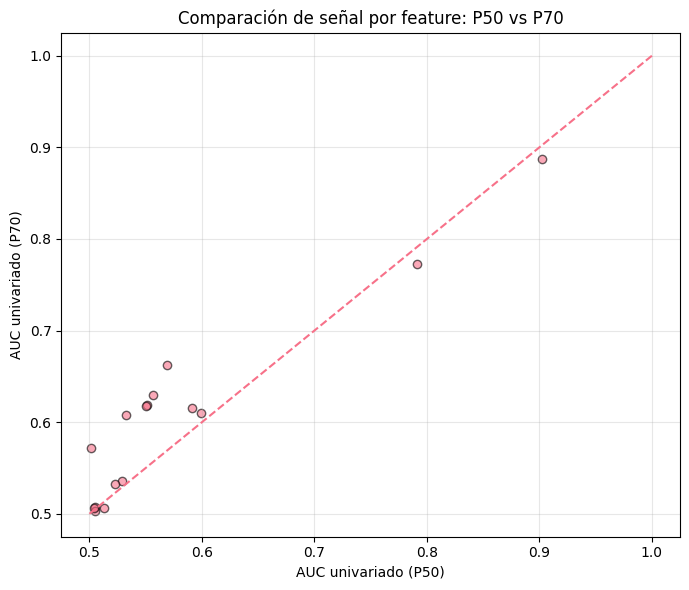

FEATURES CON MAYOR CAMBIO DE RANKING (AUC) ENTRE P50 y P70


,feature,auc_univariate_p50,corr_pointbiserial_p50,cohen_d_p50,missing_rate_p50,auc_univariate_p70,corr_pointbiserial_p70,cohen_d_p70,missing_rate_p70,rank_auc_p50,rank_auc_p70,rank_diff
15,playlist_avg_duration,0.50,-0.02,-0.04,0.06,0.57,0.08,0.18,0.06,16.00,10.00,6.00
2,artist_track_count,0.60,0.06,0.12,0.00,0.61,0.09,0.20,0.00,3.00,8.00,5.00
3,playlist_track_count,0.59,-0.16,-0.32,0.06,0.62,-0.19,-0.41,0.06,4.00,7.00,3.00
5,artist_popularity_std,0.56,0.10,0.20,0.17,0.63,0.23,0.49,0.17,6.00,4.00,2.00
6,years_since_release,0.55,0.08,0.17,0.00,0.62,0.17,0.37,0.00,7.00,5.00,2.00
7,album_release_year,0.55,-0.09,-0.17,0.00,0.62,-0.17,-0.37,0.00,8.00,6.00,2.00
11,artist_name_length,0.51,-0.03,-0.06,0.00,0.51,-0.02,-0.04,0.00,12.00,14.00,2.00
4,playlist_popularity_std,0.57,0.10,0.20,0.06,0.66,0.26,0.59,0.06,5.00,3.00,2.00
13,added_day_of_week_num,0.50,-0.34,-0.73,0.97,0.50,-0.27,-0.57,0.97,14.00,16.00,2.00
9,track_name_length,0.53,0.05,0.09,0.00,0.54,0.05,0.12,0.00,10.00,11.00,1.00


In [26]:
# ============================================================
# Evaluación de features potenciales para P50 y P70 + comparación
# ============================================================

def cohen_d(x0, x1):
    """Efecto estandarizado (Cohen's d) entre dos grupos."""
    x0 = pd.Series(x0).dropna()
    x1 = pd.Series(x1).dropna()
    if len(x0) < 2 or len(x1) < 2:
        return np.nan
    s0 = x0.std(ddof=1)
    s1 = x1.std(ddof=1)
    sp = np.sqrt(((len(x0)-1)*(s0**2) + (len(x1)-1)*(s1**2)) / (len(x0)+len(x1)-2))
    if sp == 0 or np.isnan(sp):
        return np.nan
    return (x1.mean() - x0.mean()) / sp

def evaluate_features(df, feature_list, target_col):
    """Devuelve tabla con métricas univariadas por feature para un target."""
    rows = []
    y = df[target_col].astype(int)

    for f in feature_list:
        x = df[f]

        # Missingness
        missing_rate = x.isna().mean()

        # Si es constante o casi constante, no sirve
        nunique = x.nunique(dropna=True)
        if nunique <= 1:
            rows.append({
                "feature": f,
                "missing_rate": missing_rate.round(2),
                "mean_0": np.nan.round(2), "mean_1": np.nan.round(2),
                "diff_means": np.nan.round(2),
                "cohen_d": np.nan.round(2),
                "corr_pointbiserial": 0.0,
                "auc_univariate": np.nan.round(2),
                "nunique": nunique
            })
            continue

        # Mean by class
        mean_0 = x[y == 0].mean()
        mean_1 = x[y == 1].mean()
        diff_means = mean_1 - mean_0

        # Point-biserial correlation ~ corr(feature, binary target)
        corr = pd.concat([x, y], axis=1).corr(numeric_only=True).iloc[0, 1]

        # Univariate AUC (si x tiene nulos, imputo con mediana para medir señal)
        x_imputed = x.fillna(x.median() if pd.api.types.is_numeric_dtype(x) else 0)
        try:
            auc = roc_auc_score(y, x_imputed)
            # AUC siempre debería ser >= 0.5 en valor absoluto interpretativo (si da <0.5, invierte señal)
            auc = max(auc, 1 - auc)
        except Exception:
            auc = np.nan

        rows.append({
            "feature": f,
            "missing_rate": missing_rate.round(2),
            "mean_0": mean_0.round(2),
            "mean_1": mean_1.round(2),
            "diff_means": diff_means.round(2),
            "cohen_d": cohen_d(x[y == 0], x[y == 1]).round(2),
            "corr_pointbiserial": corr.round(2),
            "auc_univariate": auc,
            "nunique": nunique
        })

    out = pd.DataFrame(rows).sort_values("auc_univariate", ascending=False)
    return out

# --------- 1) Evaluación separada (P50 y P70) ----------
features_to_score = new_features  # usa la lista que ya definiste en tu notebook

eval_p50 = evaluate_features(df, features_to_score, "target_p50")
eval_p70 = evaluate_features(df, features_to_score, "target_p70")

print("="*80)
print("TOP FEATURES (P50) por AUC univariado")
print("="*80)
display(eval_p50.head(15))

print("="*80)
print("TOP FEATURES (P70) por AUC univariado")
print("="*80)
display(eval_p70.head(15))

# --------- 2) Comparación P50 vs P70 ----------
comp = (
    eval_p50[["feature", "auc_univariate", "corr_pointbiserial", "cohen_d", "missing_rate"]]
    .merge(
        eval_p70[["feature", "auc_univariate", "corr_pointbiserial", "cohen_d", "missing_rate"]],
        on="feature",
        suffixes=("_p50", "_p70")
    )
)

# Rank stability (AUC)
comp["rank_auc_p50"] = comp["auc_univariate_p50"].rank(ascending=False, method="average")
comp["rank_auc_p70"] = comp["auc_univariate_p70"].rank(ascending=False, method="average")
comp["rank_diff"] = (comp["rank_auc_p70"] - comp["rank_auc_p50"]).abs()

# Spearman rank correlation (estabilidad del ranking)
rho, pval = spearmanr(comp["rank_auc_p50"], comp["rank_auc_p70"], nan_policy="omit")
print("="*80)
print(f"ESTABILIDAD DEL RANKING (Spearman) entre P50 y P70: rho={rho:.3f} | p-value={pval:.4g}")
print("="*80)

# Tabla ordenada: features más estables + más predictivas en P70
comp_sorted = comp.sort_values(["auc_univariate_p70", "rank_diff"], ascending=[False, True])
display(comp_sorted.head(25))

# --------- 3) Visual comparativa AUC: P50 vs P70 ----------
plt.figure(figsize=(7, 6))
plt.scatter(comp["auc_univariate_p50"], comp["auc_univariate_p70"], alpha=0.6, edgecolor="black")
plt.plot([0.5, 1.0], [0.5, 1.0], linestyle="--")
plt.xlabel("AUC univariado (P50)")
plt.ylabel("AUC univariado (P70)")
plt.title("Comparación de señal por feature: P50 vs P70")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------- 4) Diferencias: features que cambian mucho de ranking ----------
print("="*80)
print("FEATURES CON MAYOR CAMBIO DE RANKING (AUC) ENTRE P50 y P70")
print("="*80)
display(comp.sort_values("rank_diff", ascending=False).head(15))


In [27]:
# ============================================================
# Criterio de seleccion final de features para modelado
# ============================================================

# Nos quedamos con features con AUC univariado >= 0.55 en P70
AUC_CUTOFF = 0.55

selected_p70 = comp_sorted[comp_sorted["auc_univariate_p70"] >= AUC_CUTOFF]["feature"].tolist()
discarded_p70 = comp_sorted[comp_sorted["auc_univariate_p70"] < AUC_CUTOFF]["feature"].tolist()

print(f"Features seleccionadas (P70, AUC >= {AUC_CUTOFF}): {len(selected_p70)}")
print(selected_p70)

print("\n" + "-"*80)
print(f"Features descartadas (P70, AUC < {AUC_CUTOFF}): {len(discarded_p70)}")
print(discarded_p70)

Features seleccionadas (P70, AUC >= 0.55): 10
['artist_avg_popularity', 'playlist_avg_popularity', 'playlist_popularity_std', 'artist_popularity_std', 'years_since_release', 'album_release_year', 'playlist_track_count', 'artist_track_count', 'artist_avg_duration', 'playlist_avg_duration']

--------------------------------------------------------------------------------
Features descartadas (P70, AUC < 0.55): 6
['track_name_length', 'album_name_length', 'added_month_sin', 'artist_name_length', 'added_month_cos', 'added_day_of_week_num']


#### 📈 Resumen Ejecutivo y Conclusiones


In [28]:
# Resumen ejecutivo completo del análisis exploratorio
print("=" * 80)
print("RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO")
print("=" * 80)

print("\n📊 DATASET:")
print(f"  • Total de registros: {len(df):,}")
print(f"  • Tracks únicos: {df['track_id'].nunique():,}")
print(f"  • Playlists únicas: {df['playlist_id'].nunique():,}")
print(f"  • Artistas únicos: {df['artist_id'].nunique():,}")
print(f"  • Álbumes únicos: {df['album_id'].nunique():,}")

print("\n🔍 CALIDAD DE DATOS:")
print(f"  • Valores nulos totales: {df.isnull().sum().sum():,}")
print(f"  • Duplicados completos: {df.duplicated().sum():,}")
print(f"  • Tracks con duración ≤ 0.1 min: {(df['duration_min'] <= 0.1).sum():,} ({(df['duration_min'] <= 0.1).sum()/len(df)*100:.2f}%)")

print("\n📈 VARIABLES NUMÉRICAS:")
print(f"  • Popularidad promedio: {df['track_popularity'].mean():.2f} (rango 0-100)")
print(f"  • Popularidad 0: {(df['track_popularity'] == 0).sum():,} ({(df['track_popularity'] == 0).sum()/len(df)*100:.2f}%)")
print(f"  • Duración promedio: {df[df['duration_min'] > 0.1]['duration_min'].mean():.2f} minutos")
print(f"  • Correlación popularidad-duración: {df['track_popularity'].corr(df['duration_min']):.3f}")

print("\n📊 VARIABLES CATEGÓRICAS:")
print(f"  • Tracks explícitos: {(df['explicit'] == True).sum():,} ({(df['explicit'] == True).sum()/len(df)*100:.2f}%)")
print(f"  • Popularidad promedio (explícitos): {df[df['explicit'] == True]['track_popularity'].mean():.2f}")
print(f"  • Popularidad promedio (no explícitos): {df[df['explicit'] == False]['track_popularity'].mean():.2f}")

print("\n📅 TEMPORAL - FECHAS DE ADICIÓN:")
print(f"  • Rango de fechas de adición: {df['added_at_dt'].min().date()} a {df['added_at_dt'].max().date()}")
print(f"  • Año con más tracks agregados: {df['added_year'].value_counts().index[0]} ({df['added_year'].value_counts().iloc[0]} tracks)")

if 'album_release_year' in df.columns:
    df_with_release = df[df['album_release_year'].notna()].copy()
    if len(df_with_release) > 0:
        print("\n📆 TEMPORAL - FECHAS DE LANZAMIENTO:")
        print(f"  • Álbumes con fecha válida: {len(df_with_release):,} ({len(df_with_release)/len(df)*100:.2f}%)")
        print(f"  • Rango de años de lanzamiento: {df_with_release['album_release_year'].min():.0f} - {df_with_release['album_release_year'].max():.0f}")
        print(f"  • Año promedio de lanzamiento: {df_with_release['album_release_year'].mean():.1f}")
        if 'years_since_release' in df.columns:
            print(f"  • Antigüedad promedio: {df_with_release['years_since_release'].mean():.1f} años")
            corr_age_pop = df_with_release['years_since_release'].corr(df_with_release['track_popularity'])
            print(f"  • Correlación antigüedad-popularidad: {corr_age_pop:.3f}")

print("\n🎵 DIVERSIDAD:")
tracks_per_playlist_mean = df.groupby('playlist_id').size().mean()
artists_per_playlist_mean = df.groupby('playlist_id')['artist_id'].nunique().mean()
print(f"  • Promedio de tracks por playlist: {tracks_per_playlist_mean:.1f}")
print(f"  • Promedio de artistas únicos por playlist: {artists_per_playlist_mean:.1f}")
print(f"  • Ratio promedio diversidad artista/playlist: {artists_per_playlist_mean/tracks_per_playlist_mean:.3f}")

tracks_per_artist = df.groupby('artist_id').size()
print(f"  • Artistas con 1 track: {(tracks_per_artist == 1).sum()} ({(tracks_per_artist == 1).sum()/len(tracks_per_artist)*100:.2f}%)")
print(f"  • Artistas con más de 10 tracks: {(tracks_per_artist > 10).sum()} ({(tracks_per_artist > 10).sum()/len(tracks_per_artist)*100:.2f}%)")

print("\n⚠️ OUTLIERS:")
outliers_pop, _, _ = detect_outliers_iqr(df, 'track_popularity')
df_duration_valid = df[df['duration_min'] > 0.1].copy()
outliers_dur, _, _ = detect_outliers_iqr(df_duration_valid, 'duration_min')
print(f"  • Outliers en popularidad: {len(outliers_pop):,} ({len(outliers_pop)/len(df)*100:.2f}%)")
print(f"  • Outliers en duración: {len(outliers_dur):,} ({len(outliers_dur)/len(df_duration_valid)*100:.2f}%)")

print("\n🎯 TARGET VARIABLE PARA ML:")
if 'popular_high' in df.columns:
    target_dist = df['popular_high'].value_counts().sort_index()
    target_dist_pct = df['popular_high'].value_counts(normalize=True).sort_index() * 100
    print(f"  • Variable target: 'popular_high' (umbral P70: {target_threshold:.0f})")
    print(f"  • Distribución: {target_dist[0]:,} (No Popular, {target_dist_pct[0]:.2f}%) vs {target_dist[1]:,} (Popular, {target_dist_pct[1]:.2f}%)")
    print(f"  • Balance de clases: {min(target_dist_pct):.2f}% / {max(target_dist_pct):.2f}%")
    print(f"  • Ratio clases: {min(target_dist) / max(target_dist):.3f}")

print("\n📝 FEATURES PARA MODELADO (P70, AUC >= 0.55):")
if 'selected_p70' in globals() and 'discarded_p70' in globals():
    selected_features = [f for f in selected_p70 if f in df.columns]
    discarded_features = [f for f in discarded_p70 if f in df.columns]

    print(f"  • Features generadas: {len(new_features)}")
    print(f"  • Features seleccionadas (finales): {len(selected_features)}")
    print(f"  • Features descartadas: {len(discarded_features)}")
    print(f"\n  • Lista final de features seleccionadas:")
    for feat in selected_features:
        print(f"    - {feat}")

    if 'comp_sorted' in globals():
        top_final = comp_sorted[comp_sorted['feature'].isin(selected_features)][['feature', 'auc_univariate_p70', 'corr_pointbiserial_p70']].head(5)
        print(f"\n  • Top 5 features seleccionadas por AUC (P70):")
        for _, row in top_final.iterrows():
            print(f"    - {row['feature']}: AUC={row['auc_univariate_p70']:.3f}, corr={row['corr_pointbiserial_p70']:.3f}")

print("\n💡 CONCLUSIONES PRINCIPALES:")
# Calcular conclusiones dinámicamente basadas en los datos actuales
null_pct = (df.isnull().sum().sum() / df.size) * 100
pop_zero_pct = ((df['track_popularity'] == 0).sum() / len(df)) * 100
corr_pop_dur = df['track_popularity'].corr(df['duration_min'])

# Evaluar calidad de datos
if null_pct < 5:
    calidad_texto = "buena calidad de datos"
elif null_pct < 10:
    calidad_texto = "calidad de datos aceptable"
else:
    calidad_texto = "calidad de datos que requiere atención"

# Evaluar distribución de popularidad
if pop_zero_pct > 30:
    dist_texto = "distribuida de forma heterogénea"
elif pop_zero_pct > 15:
    dist_texto = "con concentración significativa en popularidad 0"
else:
    dist_texto = "distribuida de forma relativamente uniforme"

# Evaluar correlación
if abs(corr_pop_dur) < 0.1:
    corr_texto = "débil"
elif abs(corr_pop_dur) < 0.3:
    corr_texto = "moderada"
else:
    corr_texto = "fuerte"

# Evaluar balance de clases del target
if 'popular_high' in df.columns:
    target_dist_pct = df['popular_high'].value_counts(normalize=True).sort_index() * 100
    balance_ratio = min(target_dist_pct) / max(target_dist_pct)
    if balance_ratio > 0.8:
        balance_texto = "muy bien balanceado"
    elif balance_ratio > 0.6:
        balance_texto = "bien balanceado"
    elif balance_ratio > 0.4:
        balance_texto = "razonablemente balanceado"
    else:
        balance_texto = "desbalanceado (considerar técnicas de balanceo)"
else:
    balance_texto = "no disponible"

selected_count = len(selected_p70) if 'selected_p70' in globals() else 0
discarded_count = len(discarded_p70) if 'discarded_p70' in globals() else 0

print(f"  1. Dataset con {calidad_texto} ({null_pct:.2f}% nulos)")
print(f"  2. Popularidad {dist_texto} ({pop_zero_pct:.2f}% con popularidad 0)")
print(f"  3. Correlación {corr_texto} entre popularidad y duración ({corr_pop_dur:.3f})")
print(f"  4. Target variable definido con balance {balance_texto} para clasificación binaria")
print(f"  5. Se seleccionaron {selected_count} features finales para modelado (y se descartaron {discarded_count})")
print("  6. Dataset listo para etapa de feature engineering y modelado")

print("\n" + "=" * 80)
print("\n📝 NOTA: Estas conclusiones son específicas para este dataset.")
print("   Para documentar conclusiones de una ejecución específica, usar:")
print("   python -m src.utils.generate_report notebooks/01_eda.ipynb")
print("   y completar reports/01_eda/ANALYSIS.md con los hallazgos.")
print("=" * 80)


RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO

📊 DATASET:
  • Total de registros: 66,156
  • Tracks únicos: 66,156
  • Playlists únicas: 389
  • Artistas únicos: 18,871
  • Álbumes únicos: 50,959

🔍 CALIDAD DE DATOS:
  • Valores nulos totales: 675,725


  • Duplicados completos: 0
  • Tracks con duración ≤ 0.1 min: 7 (0.01%)

📈 VARIABLES NUMÉRICAS:
  • Popularidad promedio: 36.40 (rango 0-100)
  • Popularidad 0: 9,389 (14.19%)
  • Duración promedio: 3.38 minutos
  • Correlación popularidad-duración: 0.000

📊 VARIABLES CATEGÓRICAS:
  • Tracks explícitos: 9,100 (13.76%)
  • Popularidad promedio (explícitos): 43.94
  • Popularidad promedio (no explícitos): 35.20

📅 TEMPORAL - FECHAS DE ADICIÓN:
  • Rango de fechas de adición: 2015-02-07 a 2026-02-24
  • Año con más tracks agregados: 2022.0 (530 tracks)

📆 TEMPORAL - FECHAS DE LANZAMIENTO:
  • Álbumes con fecha válida: 66,121 (99.95%)
  • Rango de años de lanzamiento: 1931 - 2026
  • Año promedio de lanzamiento: 2016.9
  • Antigüedad promedio: 8.8 años
  • Correlación antigüedad-popularidad: 0.066

🎵 DIVERSIDAD:


  • Promedio de tracks por playlist: 159.7
  • Promedio de artistas únicos por playlist: 81.1
  • Ratio promedio diversidad artista/playlist: 0.508
  • Artistas con 1 track: 11033 (58.47%)
  • Artistas con más de 10 tracks: 1155 (6.12%)

⚠️ OUTLIERS:
  • Outliers en popularidad: 0 (0.00%)
  • Outliers en duración: 2,066 (3.12%)

🎯 TARGET VARIABLE PARA ML:
  • Variable target: 'popular_high' (umbral P70: 51)
  • Distribución: 45,560 (No Popular, 68.87%) vs 20,596 (Popular, 31.13%)
  • Balance de clases: 31.13% / 68.87%
  • Ratio clases: 0.452

📝 FEATURES PARA MODELADO (P70, AUC >= 0.55):
  • Features generadas: 16
  • Features seleccionadas (finales): 10
  • Features descartadas: 6

  • Lista final de features seleccionadas:
    - artist_avg_popularity
    - playlist_avg_popularity
    - playlist_popularity_std
    - artist_popularity_std
    - years_since_release
    - album_release_year
    - playlist_track_count
    - artist_track_count
    - artist_avg_duration
    - playlist_avg_du

#### 💾 Guardado del Dataset Intermedio


In [29]:
# Guardar dataset intermedio con target definido
print("=" * 80)
print("GUARDADO DEL DATASET INTERMEDIO")
print("=" * 80)

# Crear directorio si no existe
INTERIM_DIR = BASE_DIR / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

# Guardar dataset con todas las features procesadas
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
output_file = INTERIM_DIR / f"spotify_tracks_interim_{timestamp}.parquet"

# Features finales seleccionadas para modelado (P70)
if 'selected_p70' not in globals() or not selected_p70:
    raise ValueError("No se encontró 'selected_p70'. Ejecutá la celda de selección de features antes de exportar.")

selected_features = [f for f in selected_p70 if f in df.columns]

# Seleccionar columnas relevantes para guardar
base_columns = [
    # IDs y nombres originales
    'track_id', 'track_name', 'album_id', 'album_name', 'artist_id', 'artist_name',
    'playlist_id', 'playlist_name',

    # Variables originales
    'track_popularity', 'duration_ms', 'explicit', 'album_release_date', 'added_at'
]

target_columns = ['popular_high', 'popular_high_p50', 'popular_high_p60']

columns_to_save = base_columns + selected_features + target_columns

# Guardar
df_export = df[columns_to_save].copy()
df_export.to_parquet(output_file, index=False)

print(f"\n✓ Dataset guardado exitosamente:")
print(f"  Archivo: {output_file}")
print(f"  Shape: {df_export.shape[0]:,} filas x {df_export.shape[1]} columnas")
print(f"  Tamaño: {output_file.stat().st_size / 1024**2:.2f} MB")
print(f"\nColumnas incluidas: {len(columns_to_save)}")
print(f"  - Variables base: {len(base_columns)}")
print(f"  - Features seleccionadas (P70): {len(selected_features)}")
print(f"  - Target variables: {len(target_columns)}")

print("\nFeatures seleccionadas exportadas:")
for feat in selected_features:
    print(f"  - {feat}")

# Resumen final
print("\n" + "=" * 80)
print("RESUMEN DEL DATASET EXPORTADO")
print("=" * 80)
print(f"\nTarget variable principal: 'popular_high' (umbral P70: {target_threshold:.0f})")
print(f"Distribución: {df_export['popular_high'].value_counts()[0]:,} (No Popular) vs {df_export['popular_high'].value_counts()[1]:,} (Popular)")
print(f"\nDataset listo para Feature Engineering y Modelado ✓")
print("=" * 80)


GUARDADO DEL DATASET INTERMEDIO

✓ Dataset guardado exitosamente:
  Archivo: /Users/nicoguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/data/interim/spotify_tracks_interim_20260301_000321.parquet
  Shape: 66,156 filas x 26 columnas
  Tamaño: 6.67 MB

Columnas incluidas: 26
  - Variables base: 13
  - Features seleccionadas (P70): 10
  - Target variables: 3

Features seleccionadas exportadas:
  - artist_avg_popularity
  - playlist_avg_popularity
  - playlist_popularity_std
  - artist_popularity_std
  - years_since_release
  - album_release_year
  - playlist_track_count
  - artist_track_count
  - artist_avg_duration
  - playlist_avg_duration

RESUMEN DEL DATASET EXPORTADO

Target variable principal: 'popular_high' (umbral P70: 51)
Distribución: 45,560 (No Popular) vs 20,596 (Popular)

Dataset listo para Feature Engineering y Modelado ✓
